In [155]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [156]:
from google.colab import drive
drive.mount('/content/drive')
# After mounting, you can access your files in '/content/drive/My Drive/'
# Replace 'path/to/your_dataset_in_drive/yellow_tripdata_2024_combined.csv' with the actual path to your file
df = pd.read_csv('/content/drive/My Drive/car_price_hackthon_sha/data/cleaned_data.csv')

if df.empty:
    print("Warning: The DataFrame loaded from 'car_price.xlsx' is empty. Please check the Excel file content or specify a sheet_name if needed.")
else:
    print("DataFrame loaded successfully!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DataFrame loaded successfully!


In [157]:
df.describe()

,Year,ConditionValue,Odometer,MMR,SellingPrice,SaleMonth,SaleYear
count,548050.000000,548050.000000,548050.000000,548050.000000,548050.000000,548050.000000,548050.000000
mean,2010.117610,30.717198,67518.362479,13853.182739,13693.539009,3.811922,2014.902516
std,3.905911,13.272000,52887.827014,9630.861478,9702.409543,3.244148,0.296616
min,1989.000000,1.000000,1.000000,25.000000,1.000000,1.000000,2014.000000
25%,2008.000000,24.000000,28136.000000,7275.000000,7000.000000,1.000000,2015.000000
50%,2012.000000,34.000000,51389.000000,12350.000000,12200.000000,2.000000,2015.000000
75%,2013.000000,41.000000,97890.750000,18400.000000,18300.000000,6.000000,2015.000000
max,2015.000000,49.000000,999999.000000,182000.000000,230000.000000,12.000000,2015.000000


In [158]:
df.head(5)

,Year,Make,Model,Trim,Body,Transmission,State,ConditionValue,Odometer,Color,Interior,Seller,MMR,SellingPrice,SaleDate,SaleMonth,SaleYear
0,2015,Kia,Sorento,LX,suv,automatic,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,2014-12-16 04:30:00,12,2014
1,2015,Kia,Sorento,LX,suv,automatic,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,2014-12-16 04:30:00,12,2014
2,2014,BMW,3 Series,328i SULEV,sedan,automatic,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,2015-01-14 20:30:00,1,2015
3,2015,Volvo,S60,T5,sedan,automatic,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,2015-01-28 20:30:00,1,2015
4,2014,BMW,6 Series Gran Coupe,650i,sedan,automatic,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,2014-12-18 04:30:00,12,2014


In [159]:
df.columns

Index(['Year', 'Make', 'Model', 'Trim', 'Body', 'Transmission', 'State',
       'ConditionValue', 'Odometer', 'Color', 'Interior', 'Seller', 'MMR',
       'SellingPrice', 'SaleDate', 'SaleMonth', 'SaleYear'],
      dtype='object')

In [160]:
# Car Age
df['CarAge'] = df['SaleYear'] - df['Year']

In [161]:
# Miles per Year
df['MilesPerYear'] = df['Odometer'] / df['CarAge'].replace(0, 1)

In [162]:
 # Market Price vs Actual selling price
df['PriceVsMarket'] = df['SellingPrice'] - df['MMR']
# ratio
df['PriceVsMarket_Pct'] = ((df['SellingPrice'] - df['MMR']) / df['MMR']) * 100
# was it deal, fair, or overpriced?
df['PricingCategory'] = pd.cut(df['PriceVsMarket_Pct'],
    bins=[-np.inf, -5, 5, np.inf],
    labels=['Underpriced', 'Fair', 'Overpriced'])

In [163]:
# Mileage Tiers
df['Mileage_Tier'] = pd.cut(df['Odometer'],
bins=[-np.inf, 30000, 90000, 150000, np.inf],
labels=['Low (<30k)', 'Average (30k-90k)', 'High (90k-150k)', 'Ultra-High (150k+)'])

In [164]:
# Age Tiers
df['Age_Tier'] = pd.cut(df['CarAge'],
bins=[-np.inf, 1, 4, 9, np.inf],
labels=['New (0-1 yrs)', 'Off-Lease (2-4 yrs)', 'Mid-Life (5-9 yrs)', 'Older (10+ yrs)'])

In [165]:
df['Condition_Tier'] = pd.cut(df['ConditionValue'],
bins=[0, 25, 35, 45, 50],
labels=['Poor', 'Fair', 'Good', 'Excellent'])

In [166]:
# Regional Mapping (Example for US States)
regions = {
'West': ['CA', 'OR', 'WA', 'NV', 'ID', 'UT', 'AZ', 'NM', 'CO', 'WY', 'MT', 'HI', 'AK'],
'Midwest': ['ND', 'SD', 'NE', 'KS', 'MN', 'IA', 'MO', 'WI', 'IL', 'MI', 'IN', 'OH'],
'South': ['TX', 'OK', 'AR', 'LA', 'MS', 'AL', 'TN', 'KY', 'GA', 'FL', 'SC', 'NC', 'VA', 'WV', 'DC', 'MD', 'DE'],
'Northeast': ['PA', 'NJ', 'NY', 'CT', 'RI', 'MA', 'VT', 'NH', 'ME']
    }
# Flatten the dictionary to map State -> Region
state_to_region = {state: region for region, states in regions.items() for state in states}

# Clean the state column and map
df['State_Clean'] = df['State'].astype(str).str.upper().str.strip()
df['Region'] = df['State_Clean'].map(state_to_region).fillna('Unknown')

In [167]:
df['Make'].unique()

array(['Kia', 'BMW', 'Volvo', 'Nissan', 'Chevrolet', 'Audi', 'Ford',
       'Hyundai', 'Buick', 'Cadillac', 'Acura', 'Lexus', 'Infiniti',
       'Jeep', 'Mercedes-Benz', 'Mitsubishi', 'Mazda', 'Mini',
       'Land Rover', 'Lincoln', 'Jaguar', 'Volkswagen', 'Toyota',
       'Subaru', 'Scion', 'Porsche', 'Dodge', 'Fiat', 'Chrysler',
       'Ferrari', 'Honda', 'GMC', 'Ram', 'Smart', 'Bentley', 'Pontiac',
       'Saturn', 'Maserati', 'Mercury', 'Hummer', 'Saab', 'Suzuki',
       'Oldsmobile', 'Isuzu', 'Geo', 'Rolls-Royce', 'Daewoo', 'Plymouth',
       'Tesla', 'Airstream', 'Aston Martin', 'Fisker', 'Lamborghini',
       'Lotus'], dtype=object)

In [168]:

# Ultra-Luxury & Exotics
exotic = [
    'Ferrari', 'Lamborghini', 'Rolls-Royce', 'Bentley', 'Aston Martin',
    'Maserati', 'Lotus', 'Fisker'
]

# Luxury & Premium
luxury = [
    'BMW', 'Mercedes-Benz', 'Audi', 'Lexus', 'Porsche', 'Cadillac', 'Infiniti',
    'Volvo', 'Acura', 'Land Rover', 'Lincoln', 'Jaguar', 'Tesla', 'Saab'
]

# Budget / Economy
budget = [
    'Kia', 'Mitsubishi', 'Suzuki', 'Fiat', 'Smart', 'Geo', 'Daewoo',
    'Saturn', 'Scion', 'Pontiac', 'Plymouth'
]

conditions = [
    df['Make'].isin(exotic),
    df['Make'].isin(luxury),
    df['Make'].isin(budget)
]

choices = ['Exotic', 'Luxury', 'Budget']

df['MarketSegment'] = np.select(conditions, choices, default='Mid-Range')

In [169]:
# Seller Performance (for KPIs)
seller_stats = df.groupby('Seller').agg(
    SellerAvgPremium=('PriceVsMarket_Pct', 'mean'),
    SellerVolume=('SellingPrice', 'count'),
    SellerAvgPrice=('SellingPrice', 'mean')
).reset_index()

df = df.merge(seller_stats, on='Seller', how='left')

In [170]:
conditions = [
    # Very new OR very low miles, but already falling apart
    (((df['Age_Tier'] == 'New (0-1 yrs)') | (df['Mileage_Tier'] == 'Low (<30k)')) &
     (df['Condition_Tier'] == 'Poor')),

    # Possible Odometer Rollback or Fake Rating
    # Very old OR very high miles, but rated as showroom quality
    (((df['Age_Tier'] == 'Older (10+ yrs)') | (df['Mileage_Tier'].isin(['High (90k-150k)', 'Ultra-High (150k+)']))) &
     (df['Condition_Tier'] == 'Excellent'))
]

choices = ['Prematurely Trashed (High Risk)', 'Suspiciously Perfect (Verify)']

df['Condition_Anomaly_Profile'] = np.select(conditions, choices, default='Expected Wear')

The insight: does Luxury depreciate faster or slower than Budget in dollar terms vs percentage?

In [171]:
df['Dollar_Depreciation_Per_Year'] = (df['MMR']) / df['CarAge'].replace(0, 1)
df['Pct_Depreciation_Per_Year'] = df['PriceVsMarket_Pct'] / df['CarAge'].replace(0, 1)

In [172]:
df.columns

Index(['Year', 'Make', 'Model', 'Trim', 'Body', 'Transmission', 'State',
       'ConditionValue', 'Odometer', 'Color', 'Interior', 'Seller', 'MMR',
       'SellingPrice', 'SaleDate', 'SaleMonth', 'SaleYear', 'CarAge',
       'MilesPerYear', 'PriceVsMarket', 'PriceVsMarket_Pct', 'PricingCategory',
       'Mileage_Tier', 'Age_Tier', 'Condition_Tier', 'State_Clean', 'Region',
       'MarketSegment', 'SellerAvgPremium', 'SellerVolume', 'SellerAvgPrice',
       'Condition_Anomaly_Profile', 'Dollar_Depreciation_Per_Year',
       'Pct_Depreciation_Per_Year'],
      dtype='object')

In [173]:
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.15)
plt.rcParams.update({'figure.dpi': 130, 'figure.facecolor': 'white'})
SEG_ORDER = ['Budget', 'Mid-Range', 'Luxury', 'Exotic']

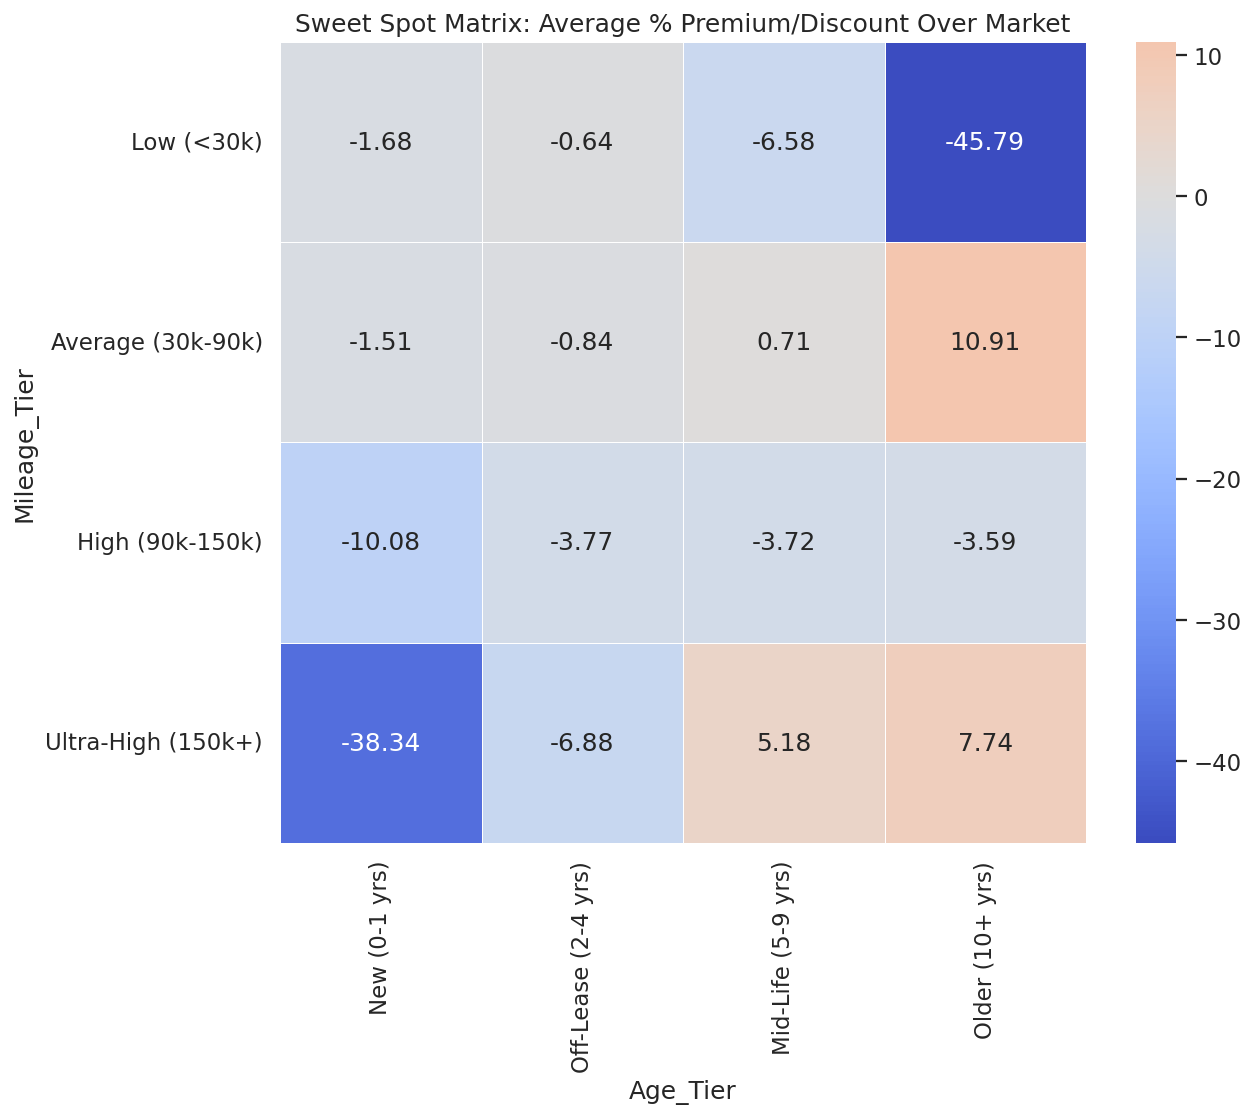

In [174]:
plt.figure(figsize=(10, 8))


heatmap_data = df.pivot_table(
    index='Mileage_Tier',
    columns='Age_Tier',
    values='PriceVsMarket_Pct',
    aggfunc='mean'
)


sns.heatmap(
    heatmap_data,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt=".2f",
    linewidths=.5
)

plt.title('Sweet Spot Matrix: Average % Premium/Discount Over Market')
plt.show()

Older (10+ yrs) / Low (<30k): A massive -45.79% discount. Why? Buyers (and dealers) suspect lot-rot, severe neglect, or rolled-back odometers.


New (0-1 yrs) / Ultra-High (150k+): A -38.34% discount. These are likely abused fleet/rental vehicles driven into the ground in a single year.


The highest premium (+10.91%) is for Older (10+ yrs) / Average (30k-90k) cars. These are the gold-standard, reliable commuter cars. Demand for these is so high that they consistently sell above their baseline market value.

<Axes: xlabel='MilesPerYear', ylabel='ConditionValue'>

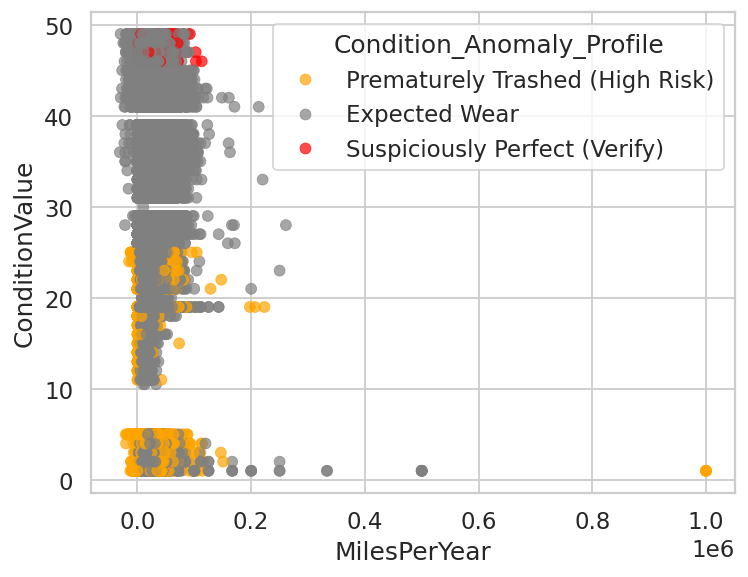

In [175]:
# Updated scatterplot with your actual feature engineering categories
sns.scatterplot(
    data=df,
    x='MilesPerYear',
    y='ConditionValue',
    hue='Condition_Anomaly_Profile',
    palette={
        'Expected Wear': 'gray',
        'Suspiciously Perfect (Verify)': 'red',
        'Prematurely Trashed (High Risk)': 'orange'
    },
    alpha=0.7,
    edgecolor=None
)

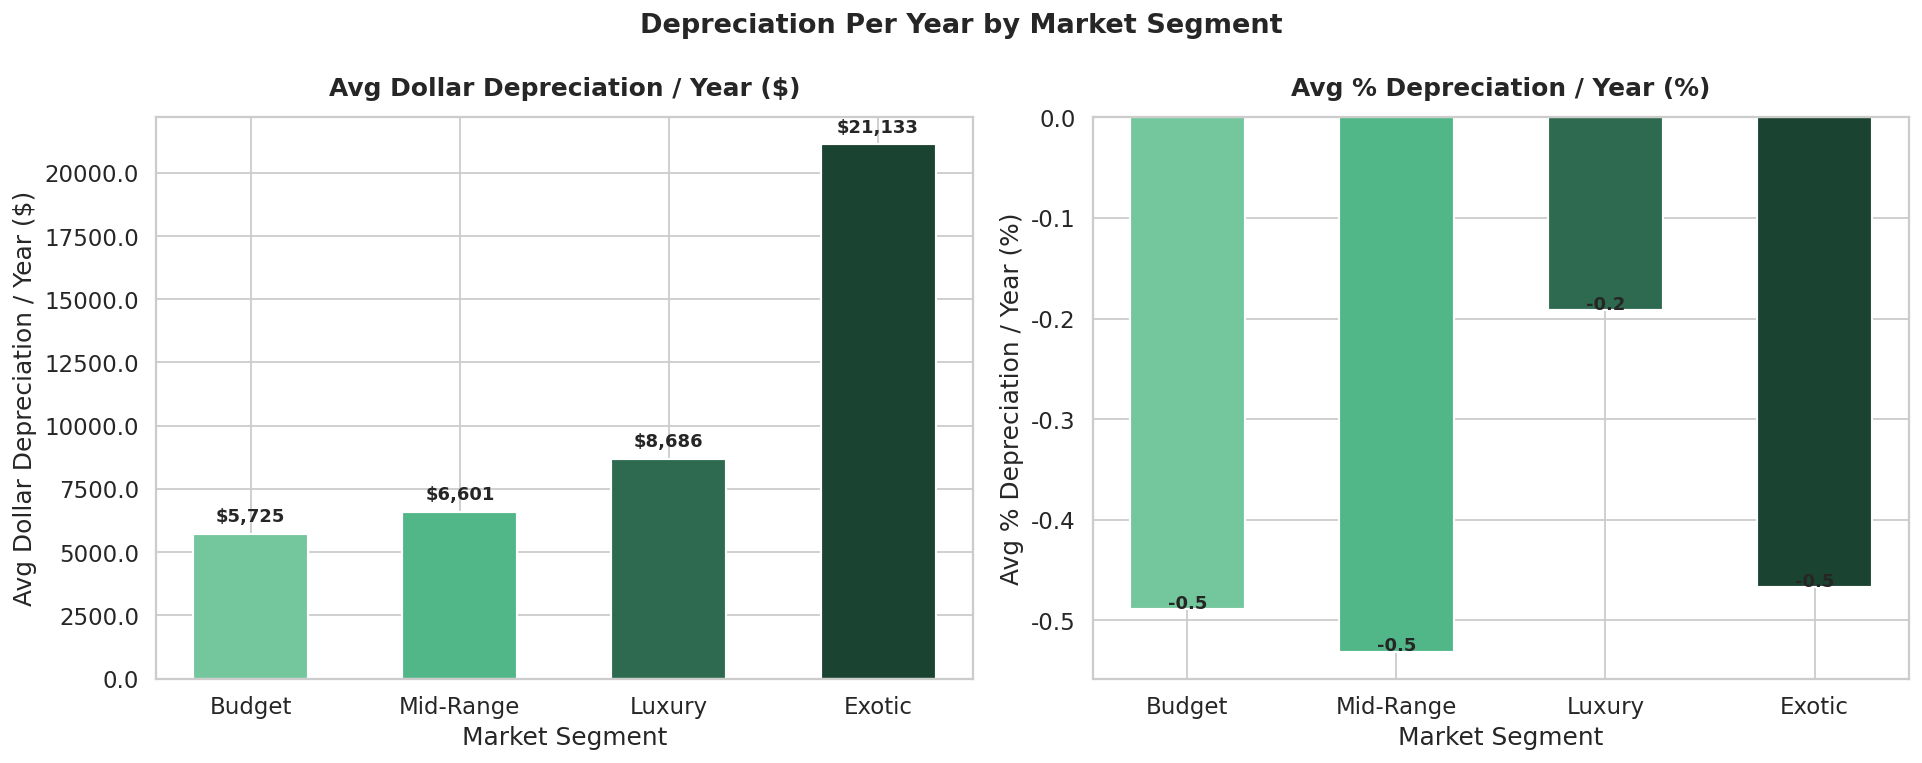


📌 Key Numbers:
               Dollar_Depreciation_Per_Year  Pct_Depreciation_Per_Year
MarketSegment                                                         
Budget                              5724.73                      -0.49
Mid-Range                           6600.53                      -0.53
Luxury                              8685.88                      -0.19
Exotic                             21133.12                      -0.47


In [176]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
palette = ['#74C69D', '#52B788', '#2D6A4F', '#1B4332']

for ax, col, label, fmt in zip(
    axes,
    ['Dollar_Depreciation_Per_Year', 'Pct_Depreciation_Per_Year'],
    ['Avg Dollar Depreciation / Year ($)', 'Avg % Depreciation / Year (%)'],
    ['${x:,.0f}', '{x:.1f}']
):
    seg_means = (
        df.groupby('MarketSegment')[col]
        .mean()
        .reindex(SEG_ORDER)
        .dropna()
    )
    bars = ax.bar(seg_means.index, seg_means.values,
                  color=palette[:len(seg_means)], width=0.55, edgecolor='white', linewidth=1.2)
    ax.set_title(label, fontweight='bold', pad=12)
    ax.set_ylabel(label)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: fmt.format(x=x)))
    ax.set_xlabel('Market Segment')
    for bar, val in zip(bars, seg_means.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + seg_means.max()*0.015,
                fmt.format(x=val), ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Depreciation Per Year by Market Segment', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📌 Key Numbers:")
print(df.groupby('MarketSegment')[['Dollar_Depreciation_Per_Year','Pct_Depreciation_Per_Year']]
        .mean().reindex(SEG_ORDER).round(2).to_string())

Luxury vehicles are the most stable asset on a percentage basis, depreciating at only -0.2%

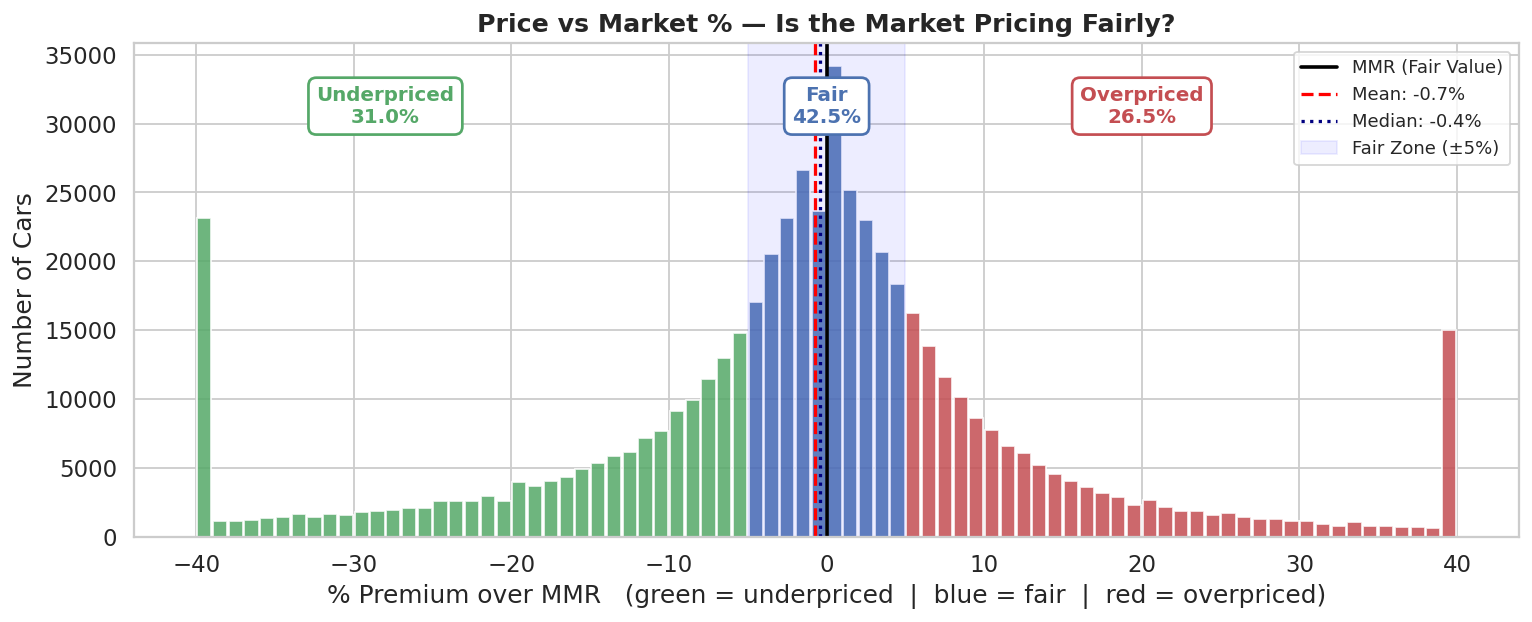

In [177]:
data       = df['PriceVsMarket_Pct'].clip(-40, 40).dropna()
mean_val   = df['PriceVsMarket_Pct'].mean()
median_val = df['PriceVsMarket_Pct'].median()

fig, ax = plt.subplots(figsize=(12, 5))

bins = np.linspace(-40, 40, 81)
counts, edges = np.histogram(data, bins=bins)

for c, left, right in zip(counts, edges[:-1], edges[1:]):
    mid   = (left + right) / 2
    color = '#C44E52' if mid > 5 else ('#55A868' if mid < -5 else '#4C72B0')
    ax.bar(mid, c, width=(right - left) * 0.9, color=color, alpha=0.85)

ax.axvline(0,          color='black', linewidth=2,   linestyle='-',  label='MMR (Fair Value)')
ax.axvline(mean_val,   color='red',   linewidth=1.8, linestyle='--', label=f'Mean: {mean_val:.1f}%')
ax.axvline(median_val, color='navy',  linewidth=1.8, linestyle=':',  label=f'Median: {median_val:.1f}%')
ax.axvspan(-5, 5, alpha=0.07, color='blue', label='Fair Zone (±5%)')

ax.set_title('Price vs Market % — Is the Market Pricing Fairly?', fontsize=14, fontweight='bold')
ax.set_xlabel('% Premium over MMR   (green = underpriced  |  blue = fair  |  red = overpriced)')
ax.set_ylabel('Number of Cars')
ax.legend(fontsize=10)

for pct_val, label, xoff, color in [
    ((data < -5).mean()*100,                        'Underpriced', -28, '#55A868'),
    (((data >= -5) & (data <= 5)).mean()*100,        'Fair',          0, '#4C72B0'),
    ((data > 5).mean()*100,                          'Overpriced',   20, '#C44E52'),
]:
    ax.text(xoff, counts.max() * 0.88,
            f'{label}\n{pct_val:.1f}%', ha='center', fontsize=11, fontweight='bold', color=color,
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor=color, linewidth=1.5))

plt.tight_layout()
plt.show()

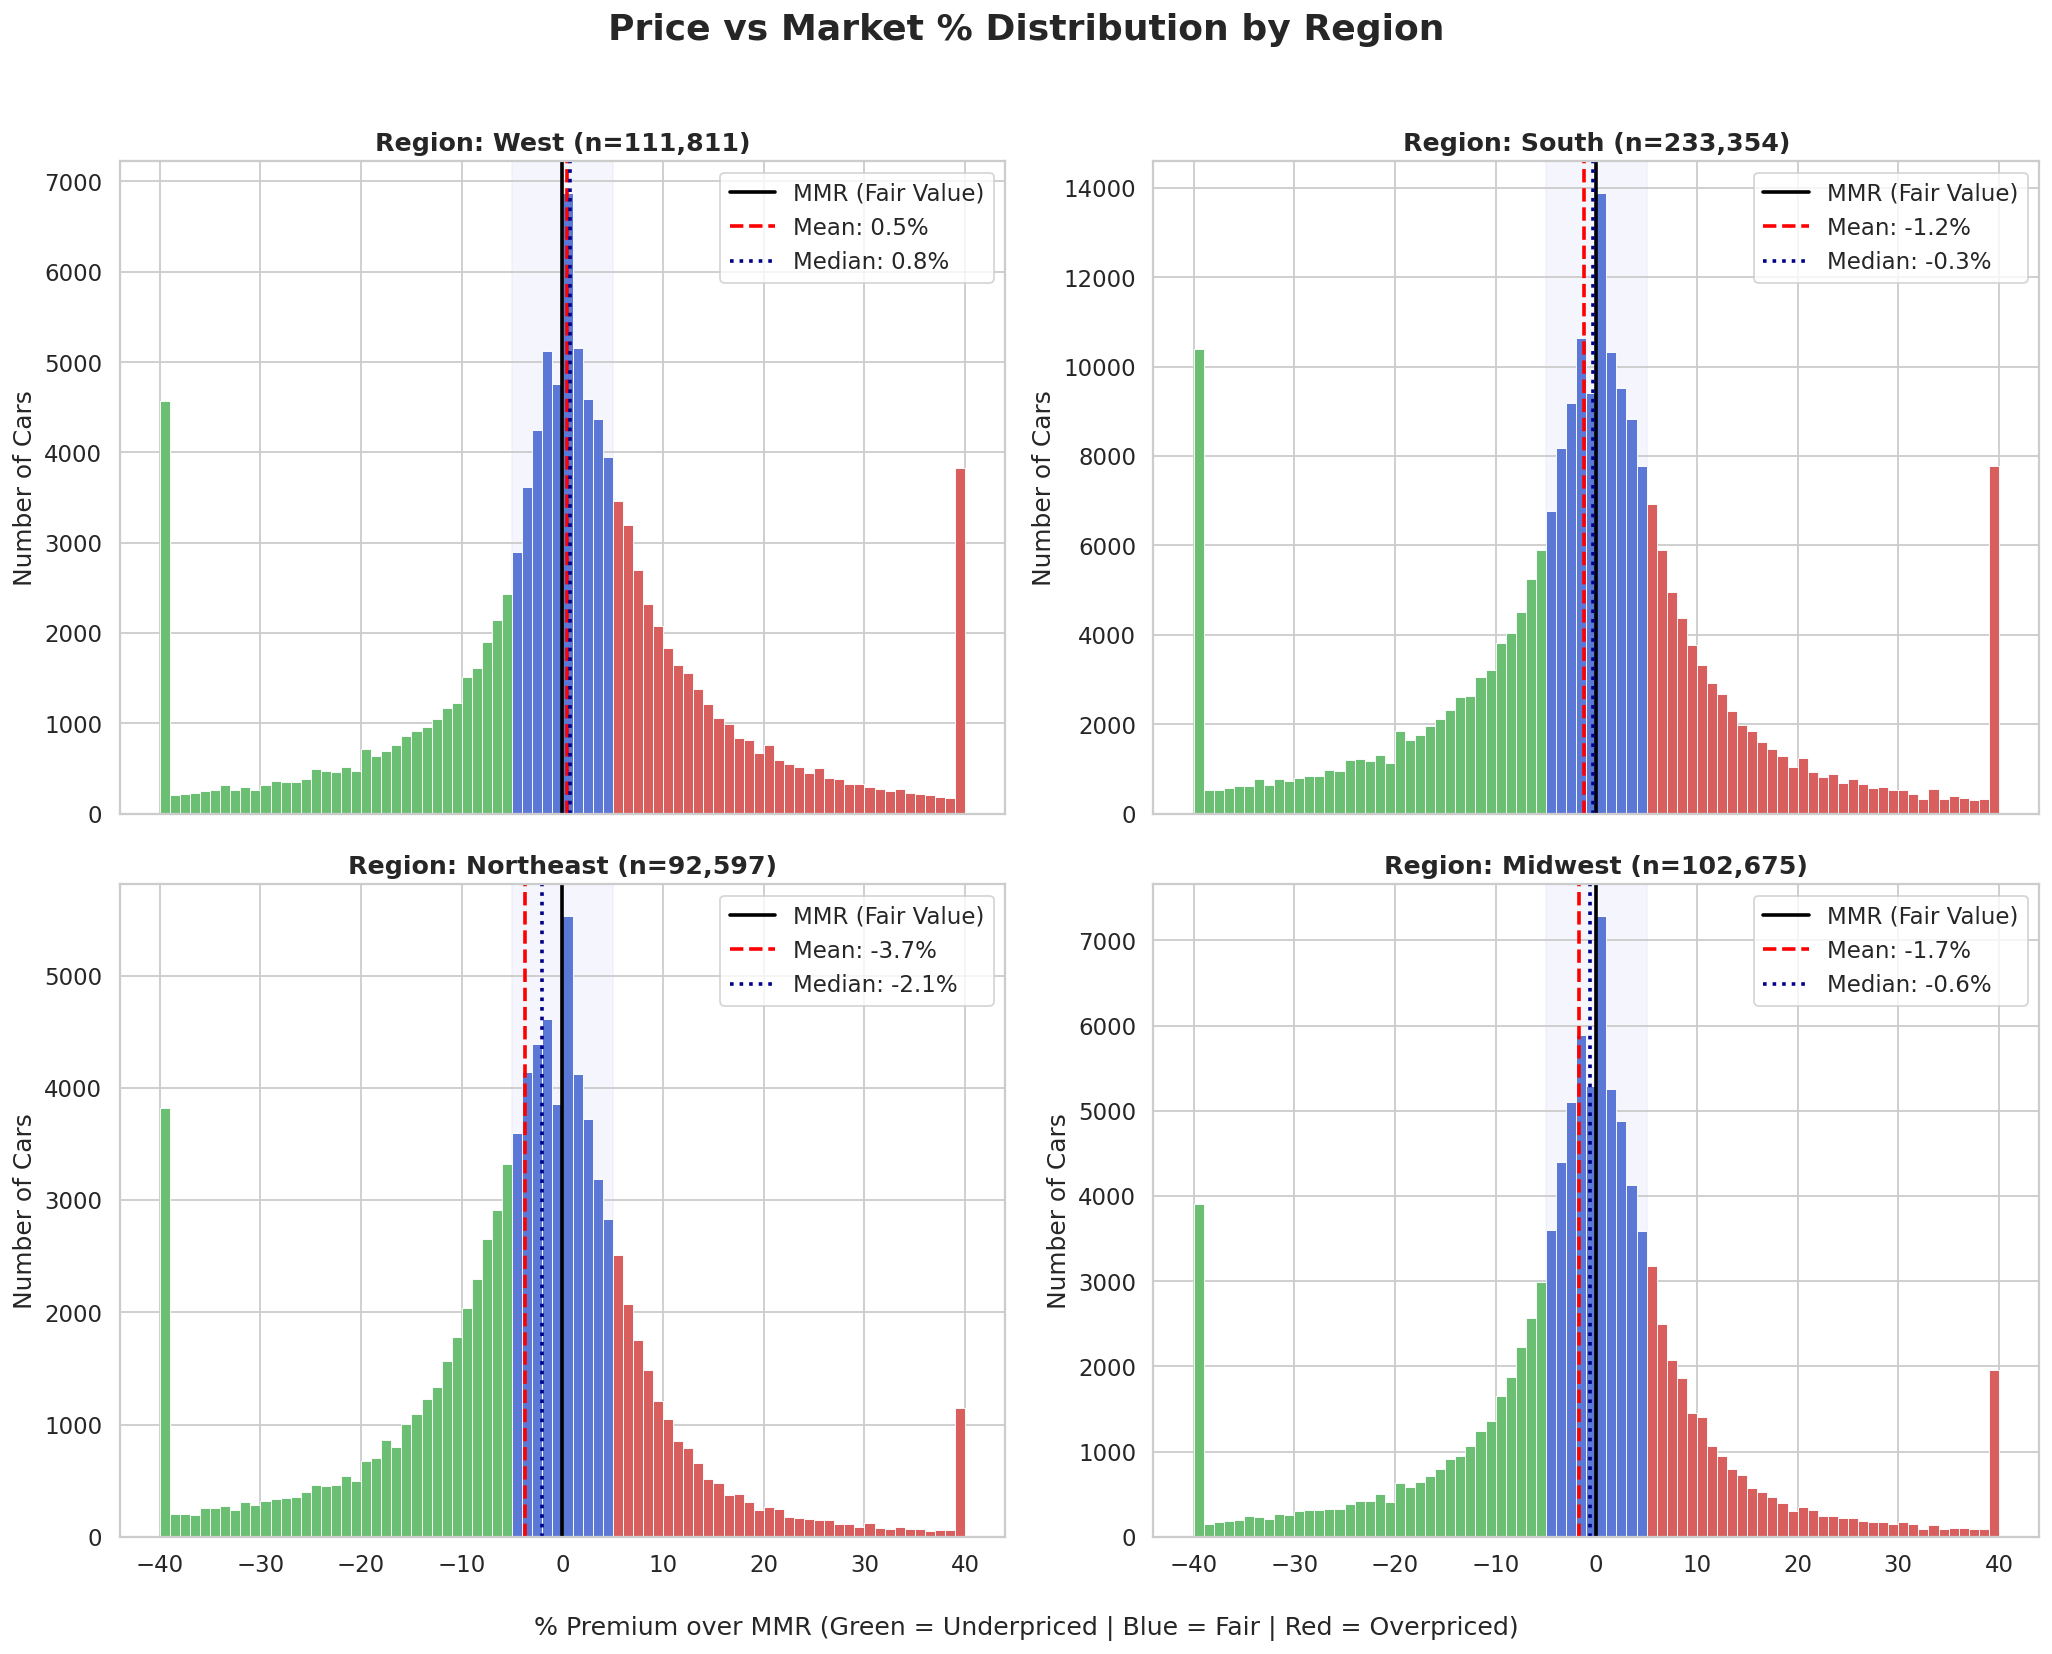

In [178]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Clean the data (Drop Unknowns/Canada as discussed previously)
# Adjust these exclusion lists based on what is actually in your 'Region' column
plot_df = df[~df['Region'].isin(['Unknown', 'Canada', 'PR', 'nan'])].copy()

# 2. Clip the data to reproduce those clean edge spikes at +/- 40
plot_df['Pct_Clipped'] = plot_df['PriceVsMarket_Pct'].clip(lower=-40, upper=40)

# Get unique, clean regions
regions = plot_df['Region'].dropna().unique()
num_regions = len(regions)

# Calculate grid size (2 columns, as many rows as needed)
cols = 2
rows = int(np.ceil(num_regions / cols))

# 3. Build the figure
# sharex=True ensures all subplots have the exact same X-axis scale for honest comparison
fig, axes = plt.subplots(rows, cols, figsize=(16, 6 * rows), sharex=True)
axes = axes.flatten()

for i, region in enumerate(regions):
    ax = axes[i]
    subset = plot_df[plot_df['Region'] == region]['Pct_Clipped'].dropna()

    # Skip regions with virtually no data to avoid breaking the chart
    if len(subset) < 100:
        continue

    # Plot the histogram
    n, bins, patches = ax.hist(subset, bins=80, edgecolor='white', linewidth=0.5)

    # Apply your exact color coding logic based on the bin edges
    for bin_val, patch in zip(bins, patches):
        if bin_val < -5:
            patch.set_facecolor('#6BBF72') # Green (Underpriced)
        elif bin_val >= 5:
            patch.set_facecolor('#D95F5F') # Red (Overpriced)
        else:
            patch.set_facecolor('#5C78D6') # Blue (Fair Zone)

    # Add the Fair Zone shading and vertical lines
    ax.axvspan(-5, 5, color='#E6E6FA', alpha=0.4, zorder=0)
    ax.axvline(0, color='black', linewidth=2, label='MMR (Fair Value)')

    mean_val = subset.mean()
    median_val = subset.median()
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.1f}%')
    ax.axvline(median_val, color='darkblue', linestyle=':', linewidth=2, label=f'Median: {median_val:.1f}%')

    # Formatting the subplot
    ax.set_title(f'Region: {region} (n={len(subset):,})', fontsize=14, fontweight='bold')
    ax.set_ylabel('Number of Cars')
    ax.legend(loc='upper right')

# Hide any extra empty subplots if you have an odd number of regions
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

# Add a master title
fig.suptitle('Price vs Market % Distribution by Region', fontsize=20, fontweight='bold', y=1.02)
fig.text(0.5, -0.02, '% Premium over MMR (Green = Underpriced | Blue = Fair | Red = Overpriced)', ha='center', fontsize=14)

plt.tight_layout()
plt.show()

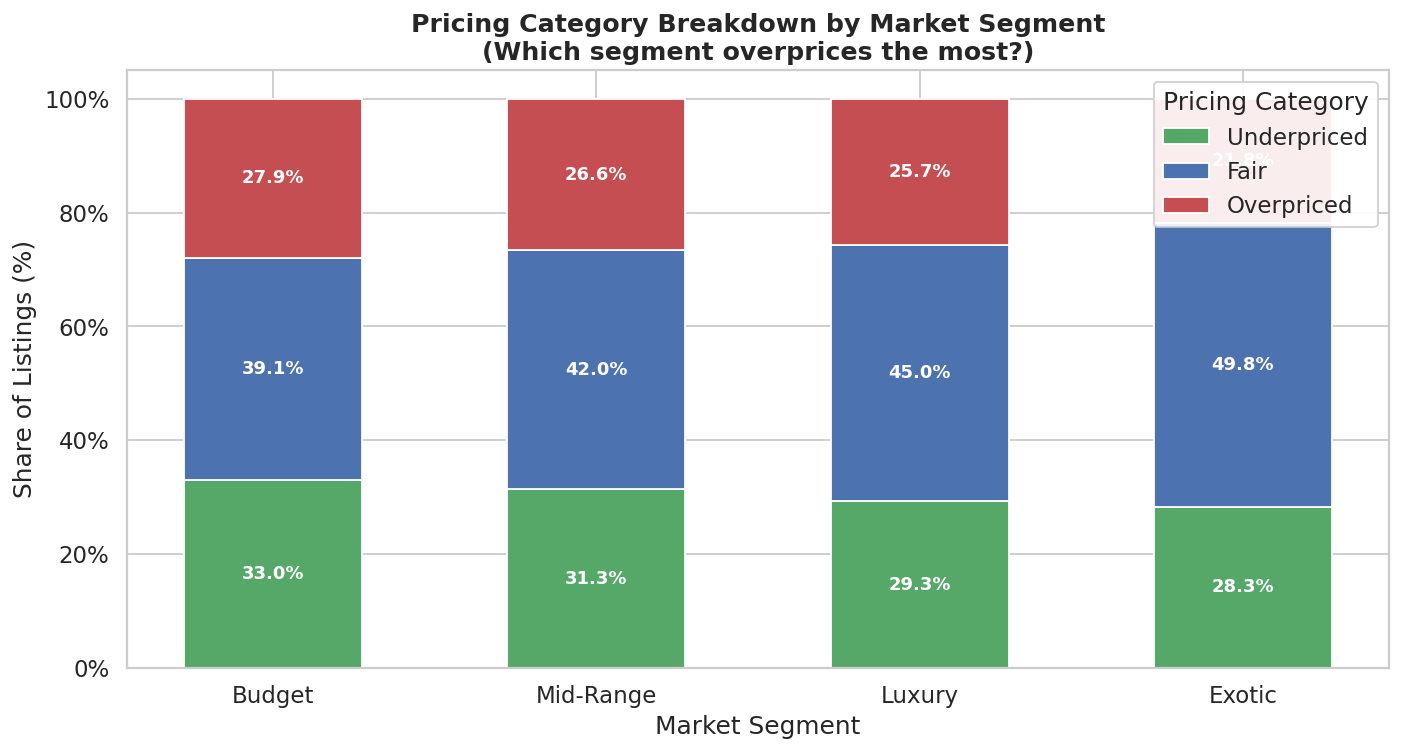


📌 Overpricing rate by segment:
MarketSegment
Budget       27.9
Mid-Range    26.6
Luxury       25.7
Exotic       21.8


In [179]:
ct = (
    df.groupby(['MarketSegment', 'PricingCategory'])
    .size()
    .unstack(fill_value=0)
    .reindex(SEG_ORDER)
)
ct_pct    = ct.div(ct.sum(axis=1), axis=0) * 100
colors_map = {'Underpriced': '#55A868', 'Fair': '#4C72B0', 'Overpriced': '#C44E52'}
cat_order  = [c for c in ['Underpriced', 'Fair', 'Overpriced'] if c in ct_pct.columns]

fig, ax = plt.subplots(figsize=(11, 6))
bottoms = np.zeros(len(ct_pct))

for cat in cat_order:
    vals = ct_pct[cat].values
    ax.bar(ct_pct.index, vals, bottom=bottoms,
           label=cat, color=colors_map[cat], width=0.55, edgecolor='white', linewidth=1)
    for i, (val, bot) in enumerate(zip(vals, bottoms)):
        if val > 4:
            ax.text(i, bot + val/2, f'{val:.1f}%', ha='center', va='center',
                    fontsize=10, fontweight='bold', color='white')
    bottoms += vals

ax.set_ylim(0, 105)
ax.set_ylabel('Share of Listings (%)')
ax.set_xlabel('Market Segment')
ax.set_title('Pricing Category Breakdown by Market Segment\n(Which segment overprices the most?)',
             fontsize=14, fontweight='bold')
ax.legend(loc='upper right', framealpha=0.9, title='Pricing Category')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))

plt.tight_layout()
plt.show()

if 'Overpriced' in ct_pct.columns:
    print("\n📌 Overpricing rate by segment:")
    print(ct_pct['Overpriced'].sort_values(ascending=False).round(1).to_string())

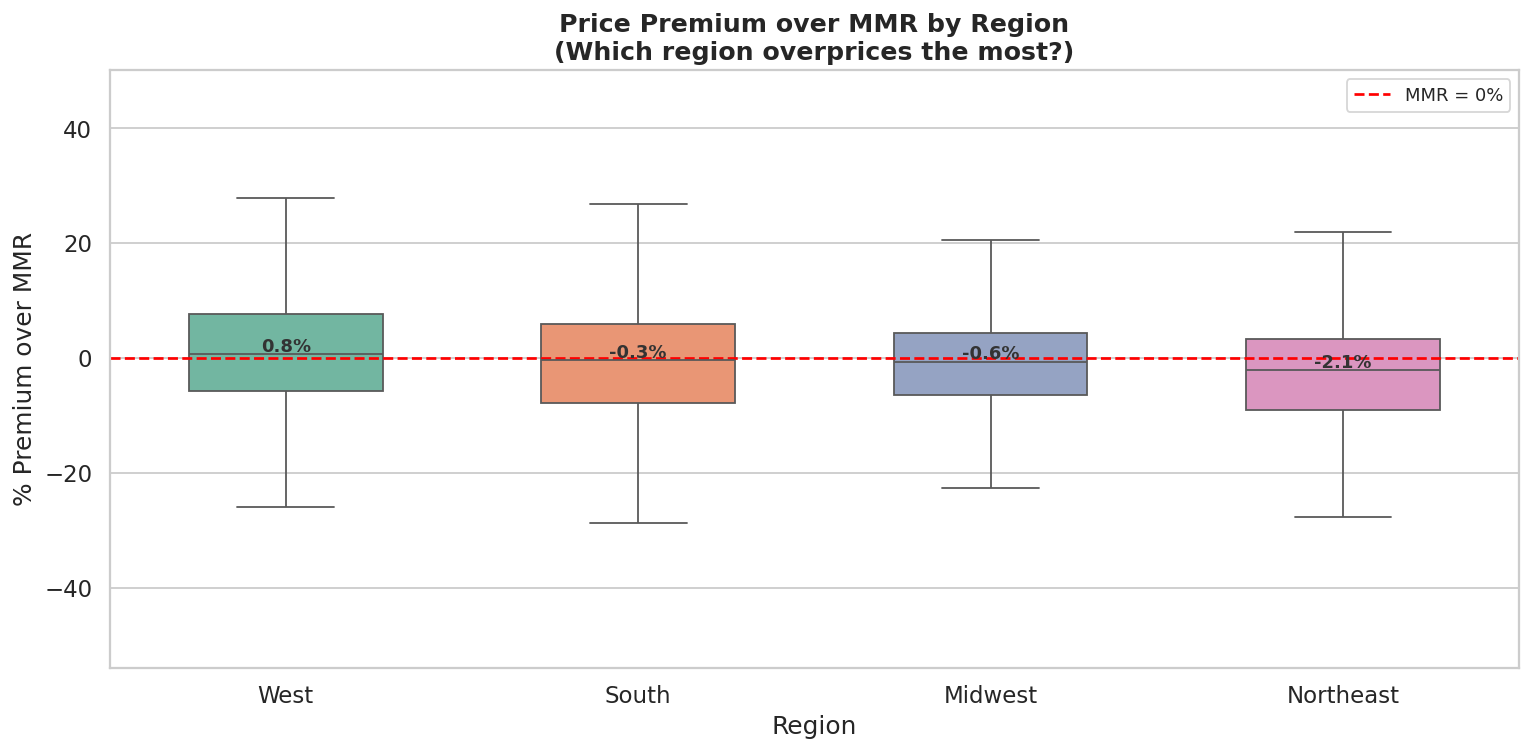

In [180]:
region_order = (
    df[df['Region'] != 'Unknown']
    .groupby('Region')['PriceVsMarket_Pct']
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)
plot_df = df[df['Region'].isin(region_order)].copy()

fig, ax = plt.subplots(figsize=(12, 6))

sns.boxplot(data=plot_df, x='Region', y='PriceVsMarket_Pct',
            order=region_order, palette='Set2', showfliers=False, width=0.55, ax=ax)

ax.axhline(0, color='red', linestyle='--', linewidth=1.5, label='MMR = 0%')

for i, region in enumerate(region_order):
    med = plot_df[plot_df['Region'] == region]['PriceVsMarket_Pct'].median()
    ax.text(i, med + 0.4, f'{med:.1f}%', ha='center', fontsize=10,
            fontweight='bold', color='#333333')

ax.set_title('Price Premium over MMR by Region\n(Which region overprices the most?)',
             fontsize=14, fontweight='bold')
ax.set_ylabel('% Premium over MMR')
ax.set_xlabel('Region')
ax.legend(fontsize=10)
ax.set_ylim(
    plot_df['PriceVsMarket_Pct'].quantile(0.02),
    plot_df['PriceVsMarket_Pct'].quantile(0.98) + 3
)

plt.tight_layout()
plt.show()

The West is the only region that consistently overprices cars, sitting just above fair market value with a median premium of +0.8%.

cars in the Northeast are systematically selling for less than they are technically worth on paper.
 The Real-World Reason: "Winter/Rust Damage"

The South (-0.3%) and Midwest (-0.6%) sit almost perfectly on the true market baseline, offering fair value with slight dealer discounts.

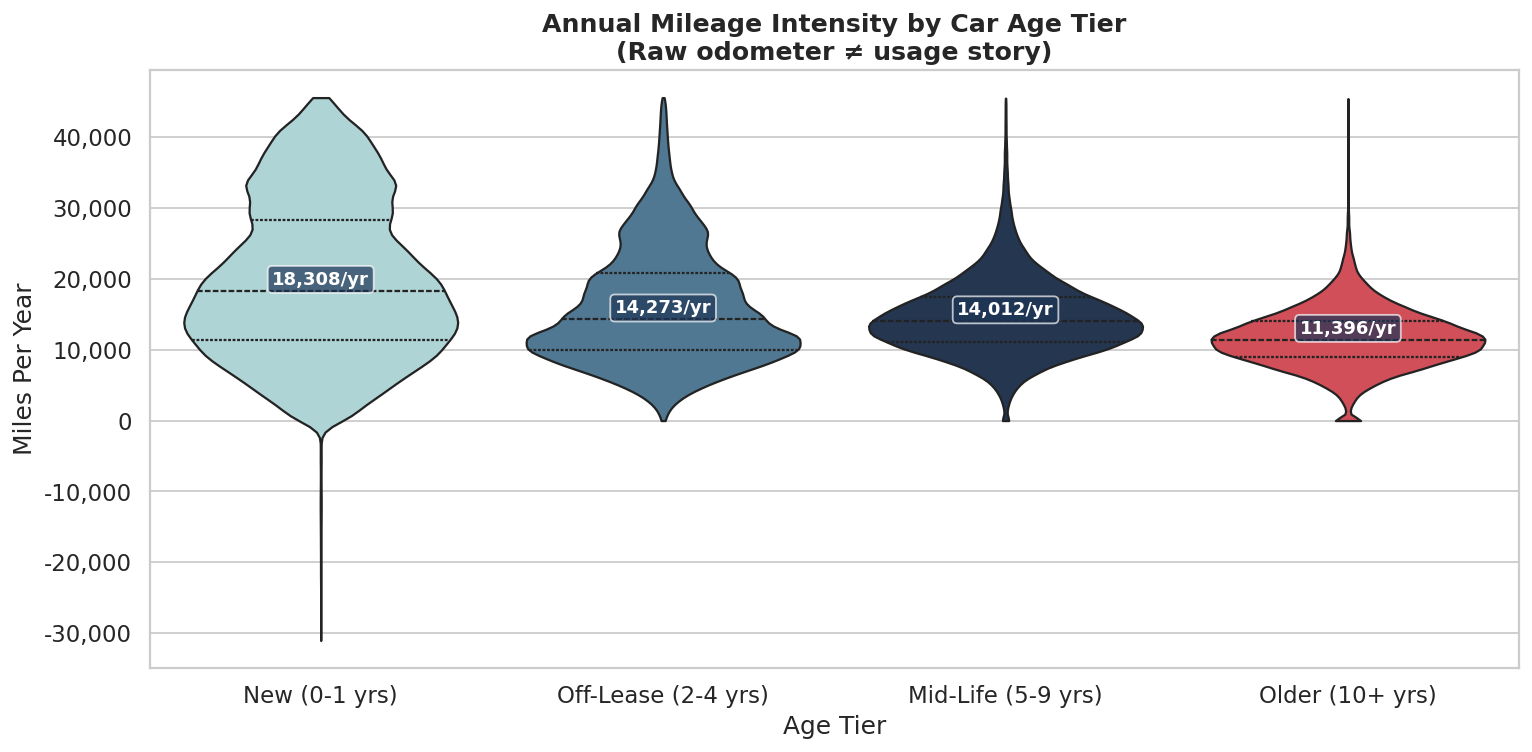

In [181]:
age_order = ['New (0-1 yrs)', 'Off-Lease (2-4 yrs)', 'Mid-Life (5-9 yrs)', 'Older (10+ yrs)']
cap     = df['MilesPerYear'].quantile(0.99)
plot_df = df[df['MilesPerYear'] <= cap].copy()

fig, ax = plt.subplots(figsize=(12, 6))

sns.violinplot(data=plot_df, x='Age_Tier', y='MilesPerYear',
               order=age_order,
               palette=['#A8DADC', '#457B9D', '#1D3557', '#E63946'],
               inner='quartile', cut=0, ax=ax)

for i, tier in enumerate(age_order):
    med = plot_df[plot_df['Age_Tier'] == tier]['MilesPerYear'].median()
    ax.text(i, med + cap * 0.02, f'{med:,.0f}/yr', ha='center', fontsize=10,
            fontweight='bold', color='white',
            bbox=dict(boxstyle='round,pad=0.25', facecolor='#1D3557', alpha=0.7))

ax.set_title('Annual Mileage Intensity by Car Age Tier\n(Raw odometer ≠ usage story)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Age Tier')
ax.set_ylabel('Miles Per Year')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

: Brand new cars are driven the hardest (18.3k miles/yr), while older cars are driven significantly less (11.4k miles/yr).


: New cars have wild usage extremes (some driven 40k+ miles), but 10+ year-old cars are almost universally used the exact same way.

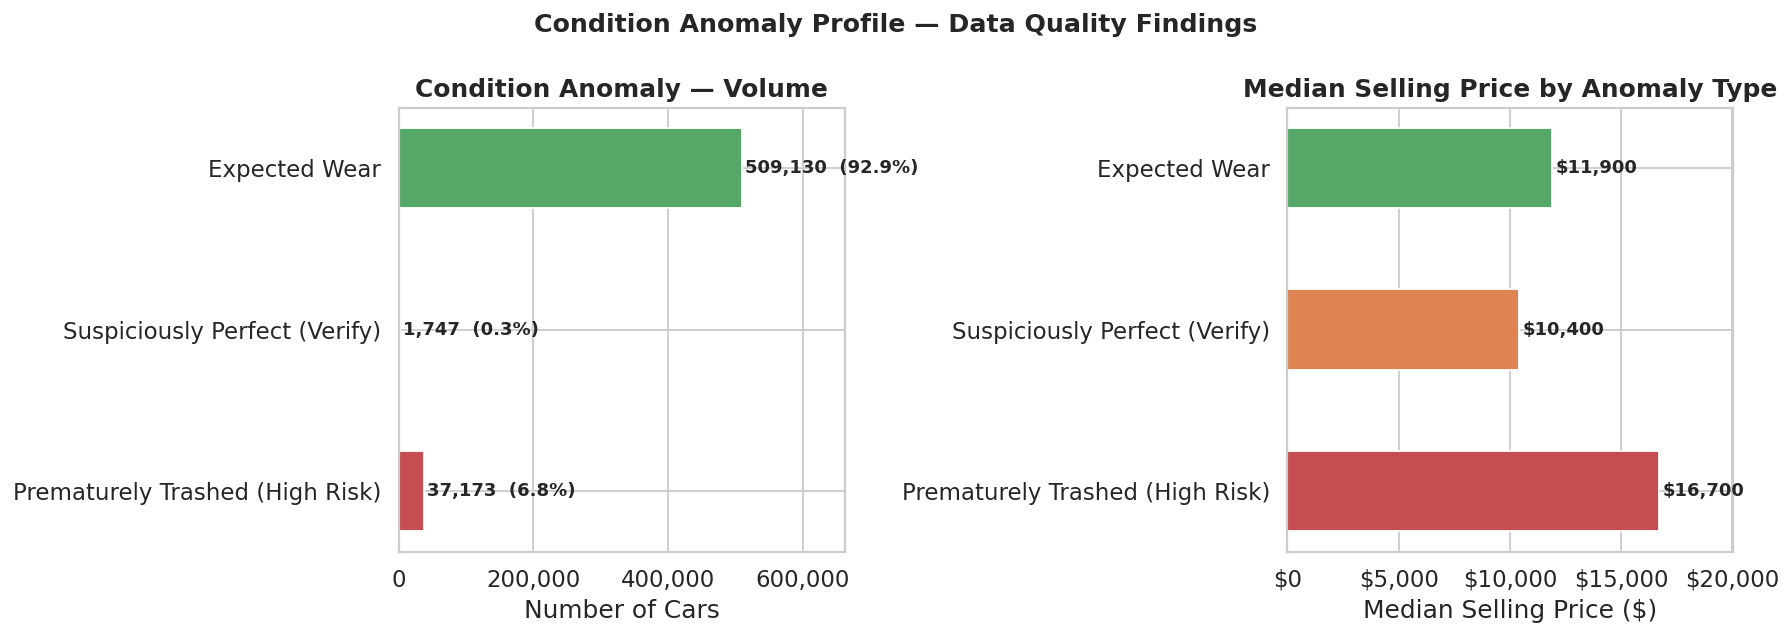


📌 38,920 listings flagged (7.1% of dataset)


In [182]:
anomaly_order  = ['Expected Wear', 'Suspiciously Perfect (Verify)', 'Prematurely Trashed (High Risk)']
anomaly_colors = {
    'Expected Wear':                      '#55A868',
    'Suspiciously Perfect (Verify)':      '#DD8452',
    'Prematurely Trashed (High Risk)':    '#C44E52'
}

counts = df['Condition_Anomaly_Profile'].value_counts().reindex(anomaly_order).dropna()
pcts   = (counts / counts.sum() * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left — count
axes[0].barh(counts.index, counts.values,
             color=[anomaly_colors[k] for k in counts.index], height=0.5)
axes[0].set_title('Condition Anomaly — Volume', fontweight='bold')
axes[0].set_xlabel('Number of Cars')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
for bar, val, pct in zip(axes[0].patches, counts.values, pcts.values):
    axes[0].text(bar.get_width() + counts.max()*0.01,
                 bar.get_y() + bar.get_height()/2,
                 f'{val:,}  ({pct}%)', va='center', fontsize=10, fontweight='bold')
axes[0].set_xlim(0, counts.max() * 1.3)
axes[0].invert_yaxis()

# Right — median price
price_by_anomaly = df.groupby('Condition_Anomaly_Profile')['SellingPrice'].median().reindex(anomaly_order).dropna()
axes[1].barh(price_by_anomaly.index, price_by_anomaly.values,
             color=[anomaly_colors[k] for k in price_by_anomaly.index], height=0.5)
axes[1].set_title('Median Selling Price by Anomaly Type', fontweight='bold')
axes[1].set_xlabel('Median Selling Price ($)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for bar, val in zip(axes[1].patches, price_by_anomaly.values):
    axes[1].text(bar.get_width() + price_by_anomaly.max()*0.01,
                 bar.get_y() + bar.get_height()/2,
                 f'${val:,.0f}', va='center', fontsize=10, fontweight='bold')
axes[1].set_xlim(0, price_by_anomaly.max() * 1.2)
axes[1].invert_yaxis()

plt.suptitle('Condition Anomaly Profile — Data Quality Findings', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

total_flagged = counts.drop('Expected Wear', errors='ignore').sum()
print(f"\n📌 {total_flagged:,} listings flagged ({total_flagged/len(df)*100:.1f}% of dataset)")

Prematurely Trashed" cars command the highest median price ($16,700), strongly implying these are newer, inherently expensive models (like rental or corporate fleets) that were abused early in their lifecycle.

Suspiciously Perfect" cars actually sell for the lowest median price ($10,400), proving the market sniffs out fake condition scores (or rollbacks) and heavily discounts them.

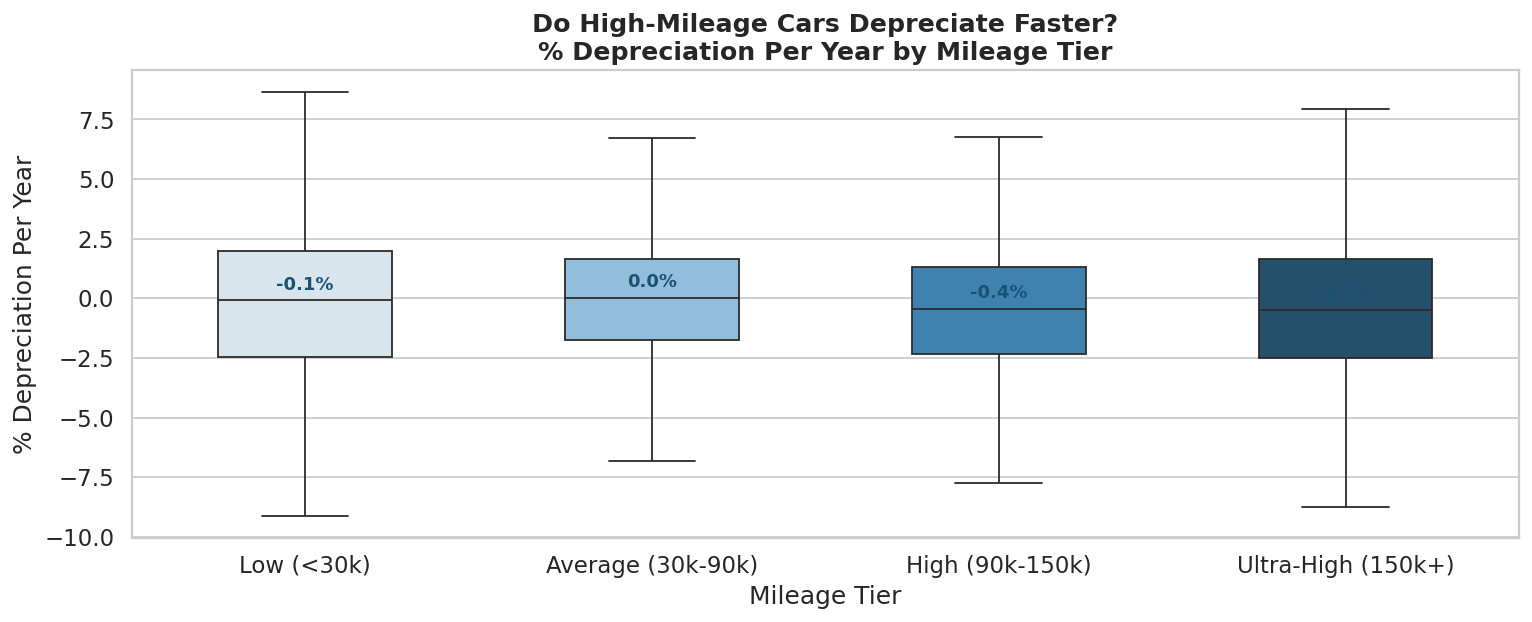


📌 Median % depreciation by mileage tier:
Mileage_Tier
Low (<30k)           -0.09
Average (30k-90k)     0.00
High (90k-150k)      -0.44
Ultra-High (150k+)   -0.48


In [183]:
mile_order = ['Low (<30k)', 'Average (30k-90k)', 'High (90k-150k)', 'Ultra-High (150k+)']
lo, cap    = df['Pct_Depreciation_Per_Year'].quantile(0.01), df['Pct_Depreciation_Per_Year'].quantile(0.99)
plot_df    = df[df['Pct_Depreciation_Per_Year'].between(lo, cap)].copy()

fig, ax = plt.subplots(figsize=(12, 5))

sns.boxplot(data=plot_df, x='Mileage_Tier', y='Pct_Depreciation_Per_Year',
            order=mile_order,
            palette=['#D4E6F1', '#85C1E9', '#2E86C1', '#1A5276'],
            showfliers=False, width=0.5, ax=ax)

for i, tier in enumerate(mile_order):
    med = plot_df[plot_df['Mileage_Tier'] == tier]['Pct_Depreciation_Per_Year'].median()
    ax.text(i, med + (cap - lo) * 0.015, f'{med:.1f}%', ha='center',
            fontsize=10, fontweight='bold', color='#1A5276')

ax.set_title('Do High-Mileage Cars Depreciate Faster?\n% Depreciation Per Year by Mileage Tier',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Mileage Tier')
ax.set_ylabel('% Depreciation Per Year')

plt.tight_layout()
plt.show()

print("\n📌 Median % depreciation by mileage tier:")
print(plot_df.groupby('Mileage_Tier')['Pct_Depreciation_Per_Year']
      .median().reindex(mile_order).round(2).to_string())

Mileage impact is shockingly minimal: Ultra-High mileage cars (150k+) only depreciate half a percent (-0.5%) faster per year than the market baseline.


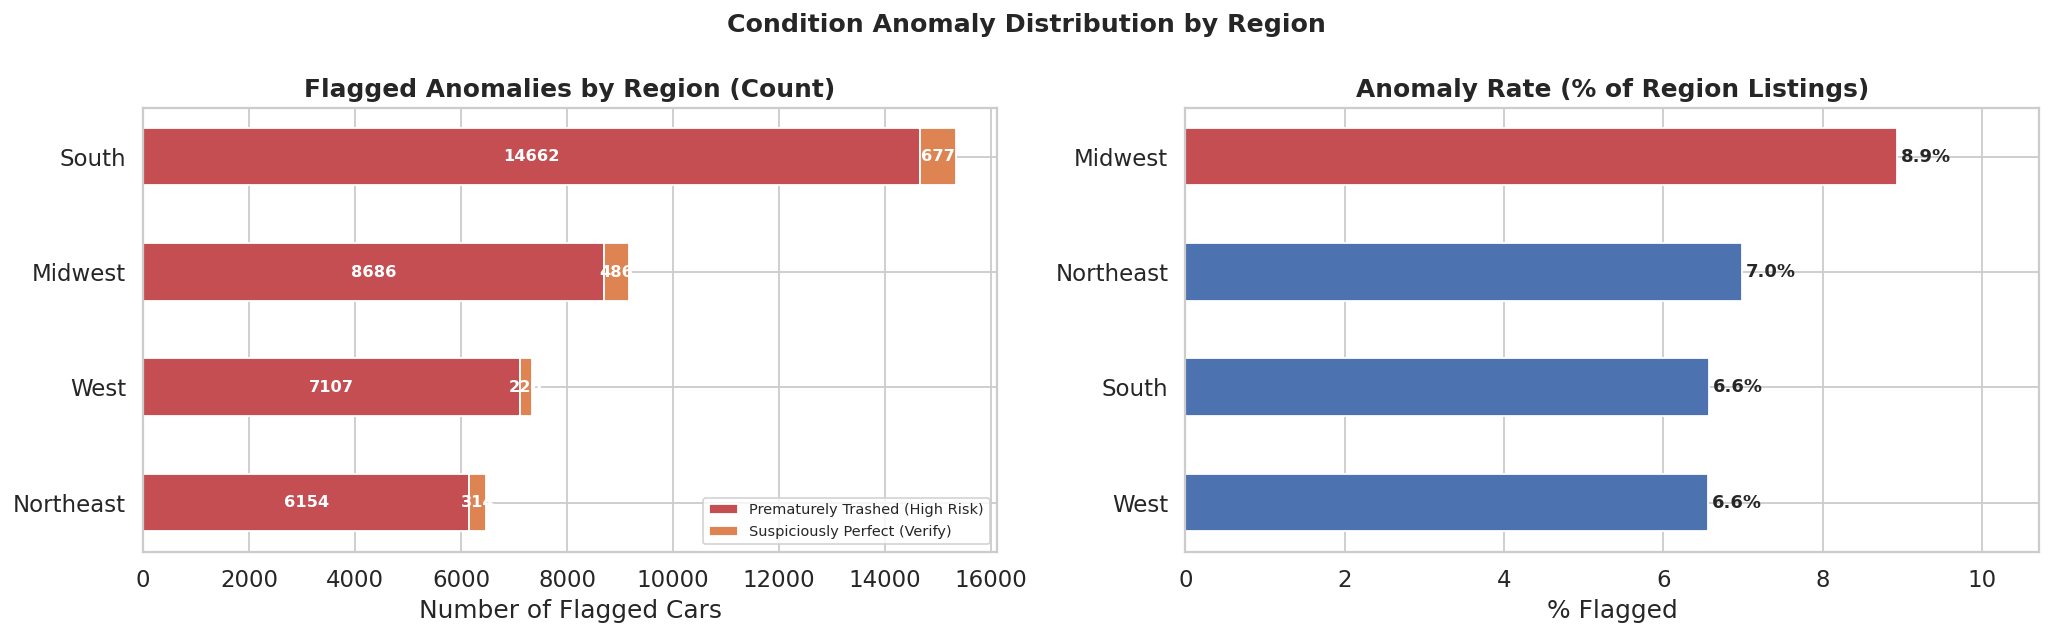

📊 INSIGHT SUMMARY — Condition Anomaly by Region

🌍 Overall:
   Total flagged listings : 38,920 (7.1% of full dataset)
   Most common anomaly type nationally : Prematurely Trashed (High Risk)
     → 36,609 cases  (94.1% of all flagged)
   Second type : Suspiciously Perfect (Verify)
     → 1,703 cases  (4.4% of all flagged)

📦 Highest Raw Count:
   South has the most flagged listings — 15,339 anomalies.
   Dominant type in South: Prematurely Trashed (High Risk)

📉 Lowest Raw Count:
   Northeast has the fewest — 6,468 anomalies.

🚨 Highest Anomaly Rate:
   Midwest has the worst rate — 8.9% of its listings are flagged.
   That is 1.8 percentage points above the national average (7.1%).
   Dominant type in Midwest: Prematurely Trashed (High Risk)

✅ Cleanest Region:
   West has the lowest anomaly rate — 6.6%.
   That is 0.5 percentage points below the national average.

📌 Cross-Finding:
   South leads in count but Midwest leads in rate.
   South is likely just a large market — its high coun

In [184]:
flagged = df[df['Condition_Anomaly_Profile'] != 'Expected Wear'].copy()

region_anomaly = (
    flagged.groupby(['Region', 'Condition_Anomaly_Profile'])
    .size()
    .unstack(fill_value=0)
    .reindex(['West', 'South', 'Midwest', 'Northeast'], fill_value=0)
)
region_anomaly['Total_Flagged'] = region_anomaly.sum(axis=1)
region_anomaly = region_anomaly.sort_values('Total_Flagged', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
colors_a = {'Prematurely Trashed (High Risk)': '#C44E52',
            'Suspiciously Perfect (Verify)':   '#DD8452'}

bottoms = np.zeros(len(region_anomaly))
for col in [c for c in region_anomaly.columns if c != 'Total_Flagged']:
    vals = region_anomaly[col].values
    axes[0].barh(region_anomaly.index, vals, left=bottoms,
                 label=col, color=colors_a.get(col, '#888'), height=0.5)
    for i, (val, bot) in enumerate(zip(vals, bottoms)):
        if val > 0:
            axes[0].text(bot + val/2, i, str(val), ha='center', va='center',
                         fontsize=9, fontweight='bold', color='white')
    bottoms += vals

axes[0].set_title('Flagged Anomalies by Region (Count)', fontweight='bold')
axes[0].set_xlabel('Number of Flagged Cars')
axes[0].legend(loc='lower right', fontsize=8)

region_total = df[df['Region'].isin(region_anomaly.index)].groupby('Region').size()
flag_rate    = (region_anomaly['Total_Flagged'] / region_total * 100).sort_values()
bar_colors   = ['#C44E52' if v == flag_rate.max() else '#4C72B0' for v in flag_rate.values]
bars = axes[1].barh(flag_rate.index, flag_rate.values, color=bar_colors, height=0.5)
axes[1].set_title('Anomaly Rate (% of Region Listings)', fontweight='bold')
axes[1].set_xlabel('% Flagged')
for bar, val in zip(bars, flag_rate.values):
    axes[1].text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')
axes[1].set_xlim(0, flag_rate.max() * 1.2)

plt.suptitle('Condition Anomaly Distribution by Region', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Computed values for insights ──────────────────────────────────────────
highest_count_region  = region_anomaly['Total_Flagged'].idxmax()
highest_count_val     = region_anomaly['Total_Flagged'].max()
lowest_count_region   = region_anomaly['Total_Flagged'].idxmin()
lowest_count_val      = region_anomaly['Total_Flagged'].min()

highest_rate_region   = flag_rate.idxmax()
highest_rate_val      = flag_rate.max()
lowest_rate_region    = flag_rate.idxmin()
lowest_rate_val       = flag_rate.min()

overall_flag_rate     = len(flagged) / len(df) * 100

# Dominant anomaly type per region
type_cols = [c for c in region_anomaly.columns if c != 'Total_Flagged']
dominant_type_per_region = region_anomaly[type_cols].idxmax(axis=1)

# Which type is more common overall
type_totals = region_anomaly[type_cols].sum().sort_values(ascending=False)

print("=" * 62)
print("📊 INSIGHT SUMMARY — Condition Anomaly by Region")
print("=" * 62)

print(f"\n🌍 Overall:")
print(f"   Total flagged listings : {len(flagged):,} ({overall_flag_rate:.1f}% of full dataset)")
print(f"   Most common anomaly type nationally : {type_totals.index[0]}")
print(f"     → {type_totals.iloc[0]:,} cases  ({type_totals.iloc[0]/len(flagged)*100:.1f}% of all flagged)")
print(f"   Second type : {type_totals.index[1]}")
print(f"     → {type_totals.iloc[1]:,} cases  ({type_totals.iloc[1]/len(flagged)*100:.1f}% of all flagged)")

print(f"\n📦 Highest Raw Count:")
print(f"   {highest_count_region} has the most flagged listings — {highest_count_val:,} anomalies.")
print(f"   Dominant type in {highest_count_region}: {dominant_type_per_region[highest_count_region]}")

print(f"\n📉 Lowest Raw Count:")
print(f"   {lowest_count_region} has the fewest — {lowest_count_val:,} anomalies.")

print(f"\n🚨 Highest Anomaly Rate:")
print(f"   {highest_rate_region} has the worst rate — {highest_rate_val:.1f}% of its listings are flagged.")
print(f"   That is {highest_rate_val - overall_flag_rate:.1f} percentage points above the national average ({overall_flag_rate:.1f}%).")
print(f"   Dominant type in {highest_rate_region}: {dominant_type_per_region[highest_rate_region]}")

print(f"\n✅ Cleanest Region:")
print(f"   {lowest_rate_region} has the lowest anomaly rate — {lowest_rate_val:.1f}%.")
print(f"   That is {overall_flag_rate - lowest_rate_val:.1f} percentage points below the national average.")

# Cross-finding: does highest count = highest rate?
print(f"\n📌 Cross-Finding:")
if highest_count_region == highest_rate_region:
    print(f"   ⚠️  {highest_count_region} leads in BOTH count and rate.")
    print(f"   This is a genuine data quality hotspot, not just a large market effect.")
else:
    print(f"   {highest_count_region} leads in count but {highest_rate_region} leads in rate.")
    print(f"   {highest_count_region} is likely just a large market — its high count reflects volume, not a quality problem.")
    print(f"   {highest_rate_region} is the real data quality concern — proportionally more suspicious listings.")

print(f"\n🔍 Dominant Anomaly Type per Region:")
for region, atype in dominant_type_per_region.items():
    count = region_anomaly.loc[region, atype]
    print(f"   {region:<12}: {atype}  ({count:,} cases)")

print("=" * 62)

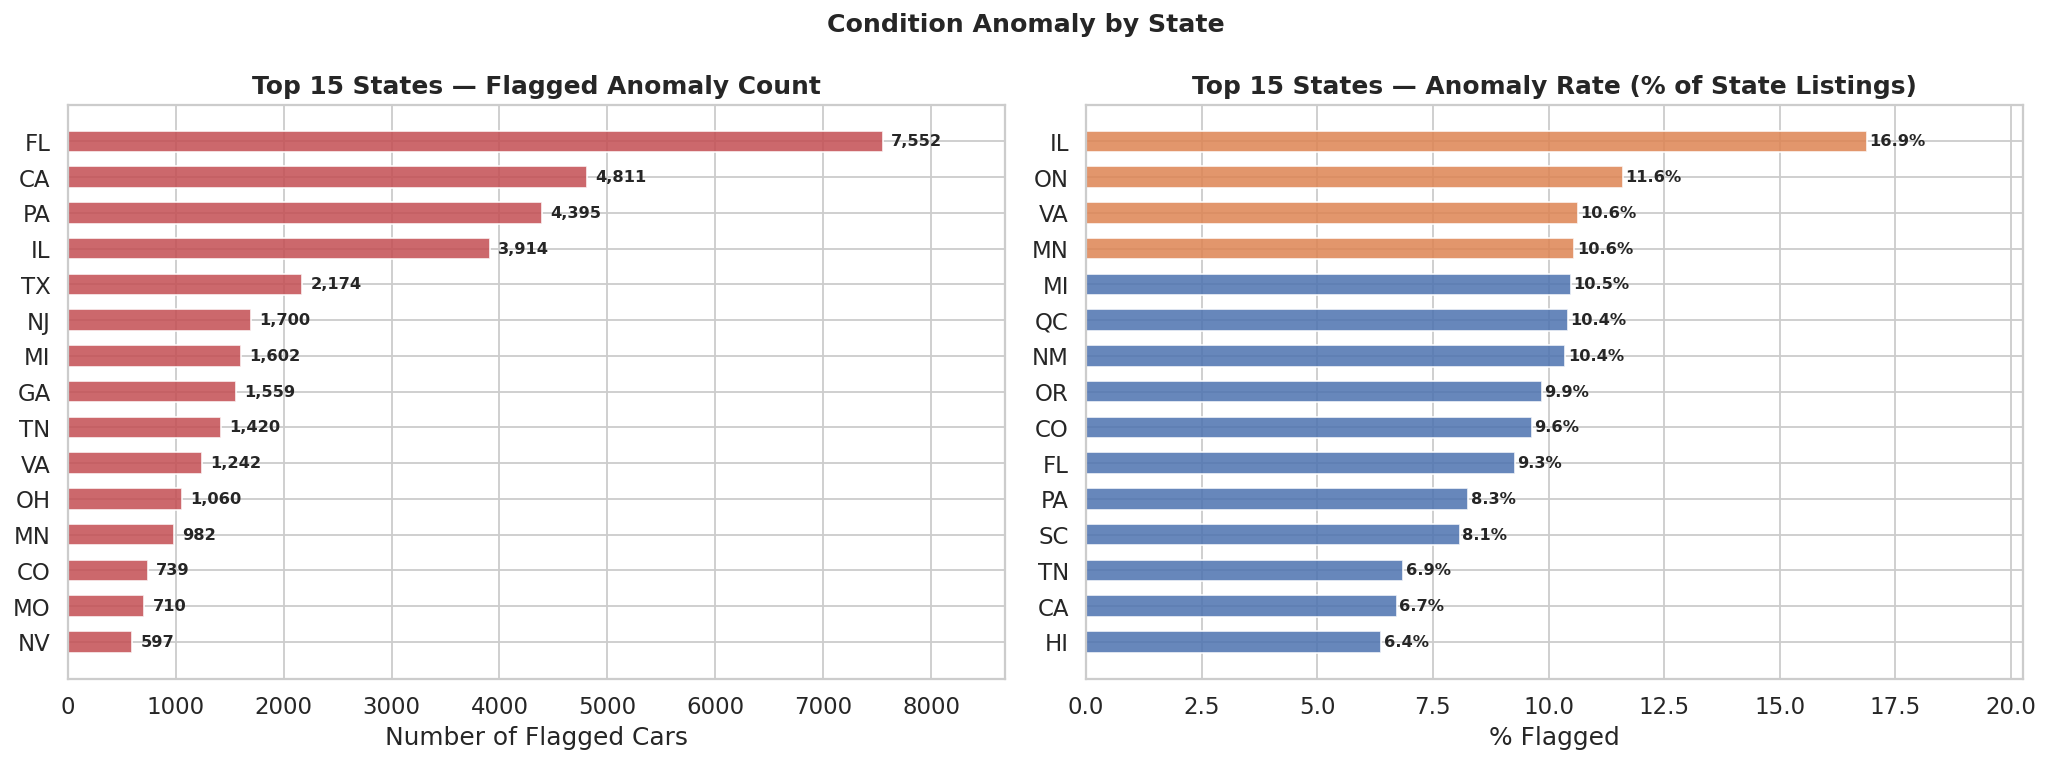

📊 INSIGHT SUMMARY — Condition Anomaly by State

🌍 Overall:
   Total flagged listings : 38,920 (7.1% of full dataset)

📦 Highest Raw Count:
   FL has the most flagged listings with 7,552 anomalies.
     → Prematurely Trashed (High Risk): 7,392
     → Suspiciously Perfect (Verify): 160

🚨 Highest Anomaly Rate:
   IL has the worst rate at 16.9% of its listings flagged.
   This is 9.8 percentage points above the national average (7.1%).
     → Prematurely Trashed (High Risk): 3,903
     → Suspiciously Perfect (Verify): 11

✅ Cleanest State (among top 15 by rate):
   HI has the lowest rate in this group at 6.4%.

📌 Top 3 States by Raw Count : FL, CA, PA
📌 Top 3 States by Rate      : IL, ON, VA

💡 No overlap between top 3 by count and top 3 by rate.
   High count states are just large markets; the rate issue is concentrated elsewhere.


In [185]:
flagged = df[df['Condition_Anomaly_Profile'] != 'Expected Wear'].copy()

state_counts = flagged.groupby('State_Clean').size()
state_total  = df.groupby('State_Clean').size()
state_rate   = (state_counts / state_total * 100).dropna().sort_values(ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_states = state_counts.sort_values(ascending=False).head(15).sort_values()
axes[0].barh(top_states.index, top_states.values,
             color='#C44E52', height=0.6, alpha=0.85)
axes[0].set_title('Top 15 States — Flagged Anomaly Count', fontweight='bold')
axes[0].set_xlabel('Number of Flagged Cars')
for bar, val in zip(axes[0].patches, top_states.values):
    axes[0].text(bar.get_width() + top_states.max()*0.01,
                 bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=9, fontweight='bold')
axes[0].set_xlim(0, top_states.max() * 1.15)

state_rate_plot = state_rate.sort_values().tail(15)
bar_colors = ['#DD8452' if v >= state_rate_plot.quantile(0.75) else '#4C72B0'
              for v in state_rate_plot.values]
bars = axes[1].barh(state_rate_plot.index, state_rate_plot.values,
                    color=bar_colors, height=0.6, alpha=0.85)
axes[1].set_title('Top 15 States — Anomaly Rate (% of State Listings)', fontweight='bold')
axes[1].set_xlabel('% Flagged')
for bar, val in zip(bars, state_rate_plot.values):
    axes[1].text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')
axes[1].set_xlim(0, state_rate_plot.max() * 1.2)

plt.suptitle('Condition Anomaly by State', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Computed values for insights ──────────────────────────────────────────
highest_count_state  = top_states.idxmax()
highest_count_val    = top_states.max()

highest_rate_state   = state_rate_plot.idxmax()
highest_rate_val     = state_rate_plot.max()

lowest_rate_state    = state_rate_plot.idxmin()
lowest_rate_val      = state_rate_plot.min()

total_flagged        = flagged.shape[0]
total_listings       = df.shape[0]
overall_flag_rate    = total_flagged / total_listings * 100

# Type breakdown per top state
top3_count_states    = top_states.sort_values(ascending=False).head(3).index.tolist()
top3_rate_states     = state_rate_plot.sort_values(ascending=False).head(3).index.tolist()

type_breakdown = (flagged.groupby(['State_Clean', 'Condition_Anomaly_Profile'])
                  .size()
                  .unstack(fill_value=0))

print("=" * 60)
print("📊 INSIGHT SUMMARY — Condition Anomaly by State")
print("=" * 60)

print(f"\n🌍 Overall:")
print(f"   Total flagged listings : {total_flagged:,} ({overall_flag_rate:.1f}% of full dataset)")

print(f"\n📦 Highest Raw Count:")
print(f"   {highest_count_state} has the most flagged listings with {highest_count_val:,} anomalies.")
if highest_count_state in type_breakdown.index:
    for atype, cnt in type_breakdown.loc[highest_count_state].items():
        if cnt > 0:
            print(f"     → {atype}: {cnt:,}")

print(f"\n🚨 Highest Anomaly Rate:")
print(f"   {highest_rate_state} has the worst rate at {highest_rate_val:.1f}% of its listings flagged.")
print(f"   This is {highest_rate_val - overall_flag_rate:.1f} percentage points above the national average ({overall_flag_rate:.1f}%).")
if highest_rate_state in type_breakdown.index:
    for atype, cnt in type_breakdown.loc[highest_rate_state].items():
        if cnt > 0:
            print(f"     → {atype}: {cnt:,}")

print(f"\n✅ Cleanest State (among top 15 by rate):")
print(f"   {lowest_rate_state} has the lowest rate in this group at {lowest_rate_val:.1f}%.")

print(f"\n📌 Top 3 States by Raw Count : {', '.join(top3_count_states)}")
print(f"📌 Top 3 States by Rate      : {', '.join(top3_rate_states)}")

overlap = set(top3_count_states) & set(top3_rate_states)
if overlap:
    print(f"\n⚠️  {', '.join(overlap)} appear in BOTH top 3 lists.")
    print(f"   These states have both high volume AND high rate of anomalies — highest data quality risk.")
else:
    print(f"\n💡 No overlap between top 3 by count and top 3 by rate.")
    print(f"   High count states are just large markets; the rate issue is concentrated elsewhere.")

print("=" * 60)

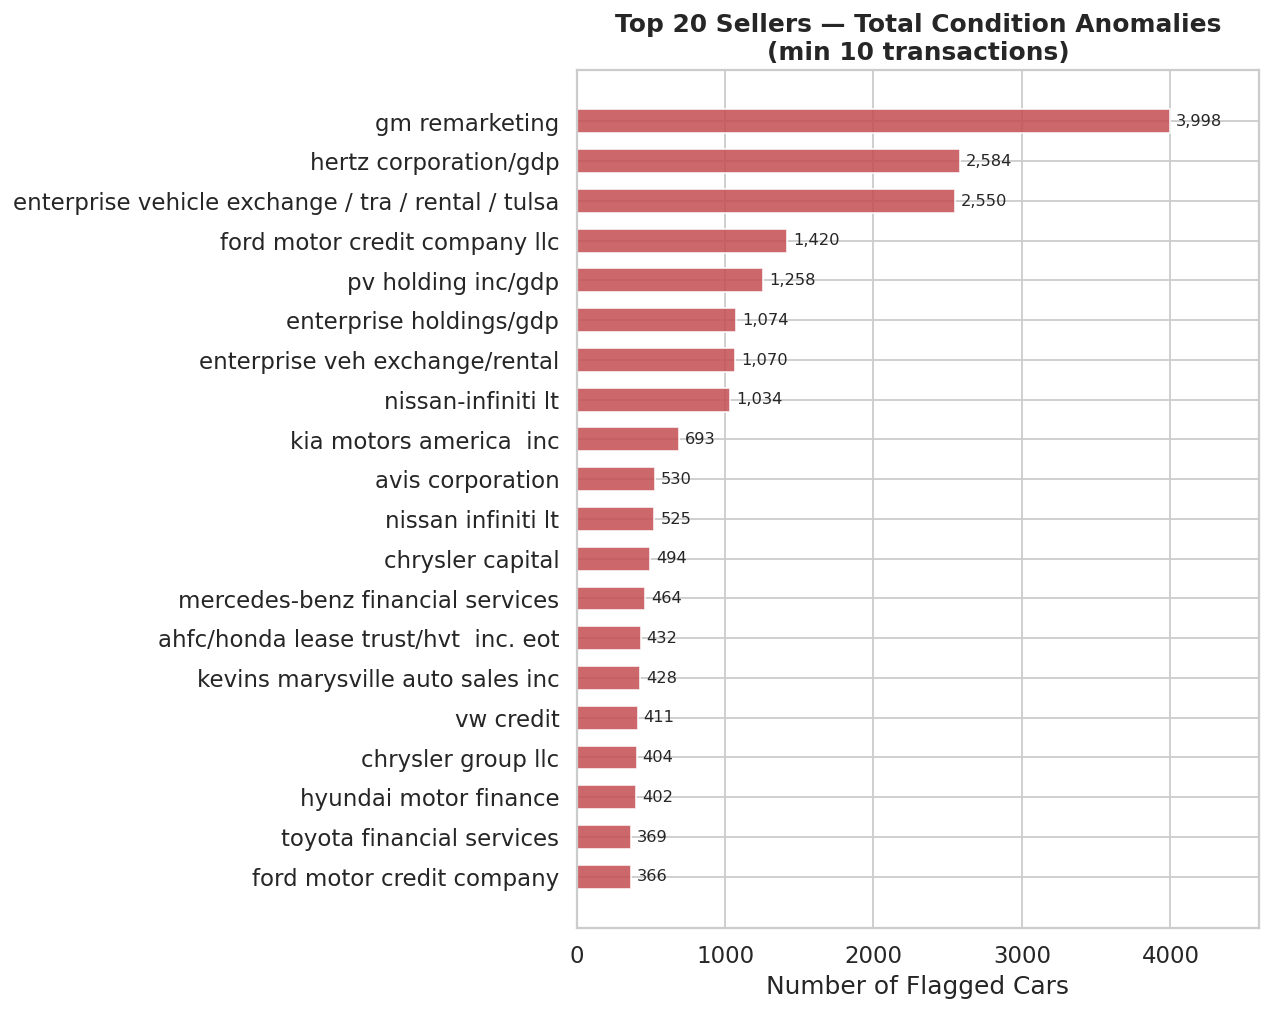

In [154]:
import matplotlib.pyplot as plt

# Filter and count
flagged = df[df['Condition_Anomaly_Profile'] != 'Expected Wear'].copy()
seller_flag_count = flagged.groupby('Seller').size()
seller_total      = df.groupby('Seller').size()

# Filter active sellers (min 10 transactions)
active_sellers = seller_total[seller_total >= 10].index

# Get top 20 by raw count
top_by_count = seller_flag_count[seller_flag_count.index.isin(active_sellers)]\
               .sort_values(ascending=False).head(20).sort_values()

# Plotting
fig, ax = plt.subplots(figsize=(10, 8))

bars = ax.barh(top_by_count.index, top_by_count.values,
               color='#C44E52', height=0.6, alpha=0.85)

ax.set_title('Top 20 Sellers — Total Condition Anomalies\n(min 10 transactions)', fontweight='bold')
ax.set_xlabel('Number of Flagged Cars')

# Add value labels
for bar, val in zip(bars, top_by_count.values):
    ax.text(bar.get_width() + top_by_count.max()*0.01,
            bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)

ax.set_xlim(0, top_by_count.max() * 1.15)

plt.tight_layout()
plt.show()

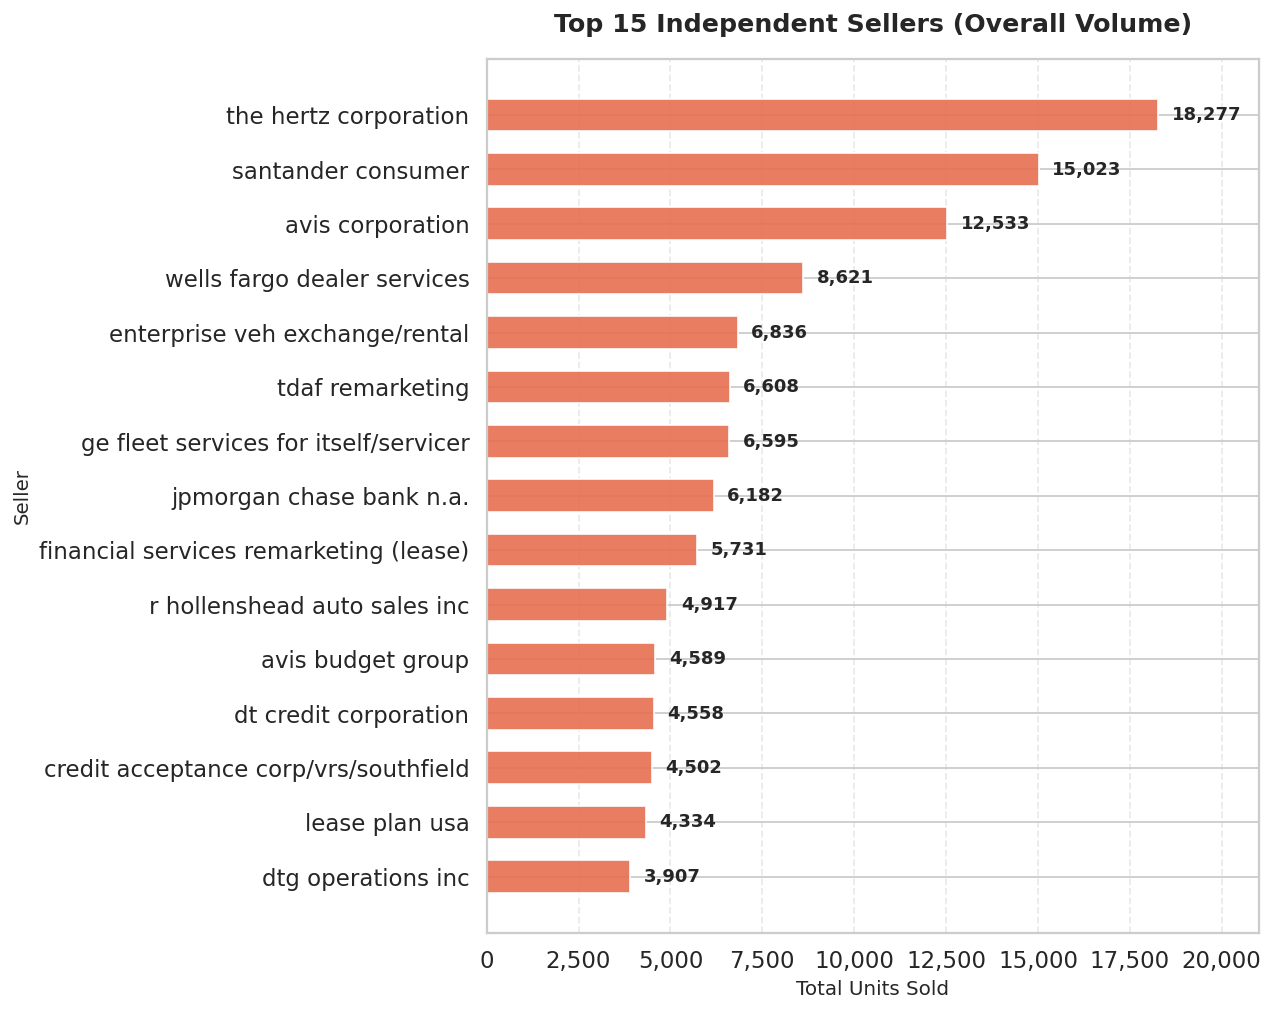


🏆 Overall Top 5 Independent Sellers:
Seller
the hertz corporation             18277
santander consumer                15023
avis corporation                  12533
wells fargo dealer services        8621
enterprise veh exchange/rental     6836


In [186]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── Official seller keywords to exclude per make ──────────────────────────
official_keywords = {
    'Ford':      ['ford', 'lincoln'],
    'Chevrolet': ['gm ', 'general motors', 'gmac', 'gm financial', 'gm remarketing'],
    'Nissan':    ['nissan', 'infiniti'],
    'Toyota':    ['toyota', 'lexus', 'tdaf'],
    'Dodge':     ['chrysler', 'dodge', 'fca', 'stellantis'],
    'Honda':     ['honda', 'ahfc', 'acura'],
    'Hyundai':   ['hyundai', 'kia motors finance'],
    'BMW':       ['bmw'],
    'Kia':       ['kia motors'],
    'Chrysler':  ['chrysler', 'fca', 'stellantis'],
}

def is_official(seller_name, make):
    # Handle potential NaN values
    if pd.isna(seller_name) or pd.isna(make):
        return False

    seller_lower = str(seller_name).lower()
    # Default to make name if not in dictionary
    for kw in official_keywords.get(make, [str(make).lower()]):
        if kw in seller_lower:
            return True
    return False

# ── 1. Filter out official sellers in one pass ────────────────────────────
# Apply the function across rows to create a boolean mask
mask = df.apply(lambda row: not is_official(row['Seller'], row['Make']), axis=1)
indep_df = df[mask]

# ── 2. Aggregate to find the overall top 15 independent sellers ───────────
# Sort ascending so the largest bar appears at the top of a horizontal plot
overall = indep_df['Seller'].value_counts().head(15).sort_values(ascending=True)

# ── 3. Plotting ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))

bars = ax.barh(overall.index, overall.values, color='#E76F51', height=0.6, alpha=0.9)

ax.set_title('Top 15 Independent Sellers (Overall Volume)', fontweight='bold', fontsize=14, pad=15)
ax.set_xlabel('Total Units Sold', fontsize=11)
ax.set_ylabel('Seller', fontsize=11)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

# Add data labels to the end of each bar
for bar, val in zip(bars, overall.values):
    ax.text(bar.get_width() + (overall.max() * 0.02),
            bar.get_y() + bar.get_height() / 2,
            f'{val:,}', va='center', fontsize=10, fontweight='bold')

# Extend x-axis slightly to ensure labels aren't cut off
ax.set_xlim(0, overall.max() * 1.15)

plt.tight_layout()
plt.show()

# ── 4. Console Output ─────────────────────────────────────────────────────
print("\n🏆 Overall Top 5 Independent Sellers:")
# Reverse the sort just for the console printout
print(overall.sort_values(ascending=False).head(5).to_string())

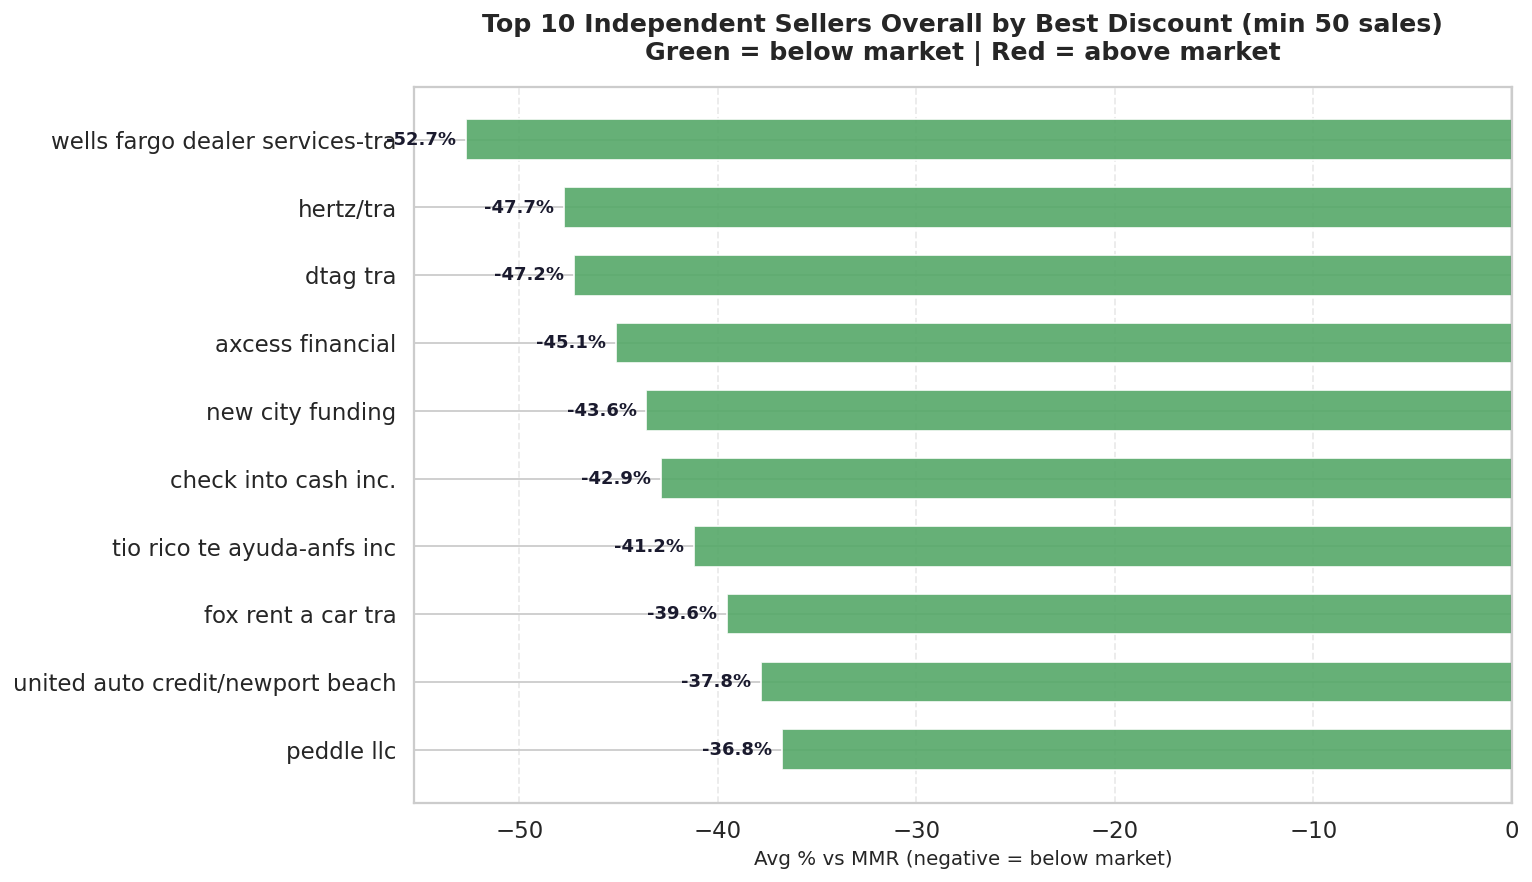


🏷️  TOP 10 BEST DISCOUNT Sellers (most below MMR, independent, overall):
                          Seller AvgPremium_Pct  TotalVolume
 wells fargo dealer services-tra        -52.68%           52
                       hertz/tra        -47.75%          673
                        dtag tra        -47.25%           68
                axcess financial        -45.12%          119
                new city funding        -43.60%           75
            check into cash inc.        -42.85%           52
      tio rico te ayuda-anfs inc        -41.22%           56
              fox rent a car tra        -39.56%          133
united auto credit/newport beach        -37.83%           73
                      peddle llc        -36.76%           70


In [187]:


# ── Same OEM exclusion logic ──────────────────────────────────────────────
official_keywords = {
    'Ford':      ['ford', 'lincoln'],
    'Chevrolet': ['gm ', 'general motors', 'gmac', 'gm financial', 'gm remarketing'],
    'Nissan':    ['nissan', 'infiniti'],
    'Toyota':    ['toyota', 'lexus', 'tdaf'],
    'Dodge':     ['chrysler', 'dodge', 'fca', 'stellantis'],
    'Honda':     ['honda', 'ahfc', 'acura'],
    'Hyundai':   ['hyundai', 'kia motors finance'],
    'BMW':       ['bmw'],
    'Kia':       ['kia motors'],
    'Chrysler':  ['chrysler', 'fca', 'stellantis'],
}

def is_official(seller_name, make):
    seller_lower = str(seller_name).lower()
    for kw in official_keywords.get(make, [make.lower()]):
        if kw in seller_lower:
            return True
    return False

MIN_SALES = 50  # ignore sellers with tiny volume — unreliable averages

# ════════════════════════════════════════════════════════════════════════════
# DATA PREPARATION — Filter and Aggregate Overall
# ════════════════════════════════════════════════════════════════════════════
# 1. Filter out official (OEM) sellers across the entire dataframe
mask = ~df.apply(lambda row: is_official(row['Seller'], row['Make']), axis=1)
df_indep = df[mask].copy()

# 2. Aggregate stats per independent seller globally
seller_stats = (
    df_indep.groupby('Seller')
    .filter(lambda x: len(x) >= MIN_SALES)
    .groupby('Seller')
    .agg(
        AvgPrice=('SellingPrice', 'mean'),
        AvgPremium_Pct=('PriceVsMarket_Pct', 'mean'),
        TotalVolume=('SellingPrice', 'count')
    )
    .reset_index()
)

top_discount = seller_stats.sort_values('AvgPremium_Pct', ascending=True).head(10)
top_discount = top_discount.sort_values('AvgPremium_Pct', ascending=False)

fig, ax = plt.subplots(figsize=(12, 7))
bar_colors = ['#C44E52' if v > 0 else '#55A868' for v in top_discount['AvgPremium_Pct']]
bars = ax.barh(top_discount['Seller'], top_discount['AvgPremium_Pct'], color=bar_colors, height=0.6, alpha=0.9)

ax.axvline(0, color='black', linewidth=1.2)
ax.set_title(f'Top 10 Independent Sellers Overall by Best Discount (min {MIN_SALES} sales)\n'
             'Green = below market | Red = above market',
             fontweight='bold', fontsize=14, pad=15)
ax.set_xlabel('Avg % vs MMR (negative = below market)', fontsize=11)
ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

for bar, val in zip(bars, top_discount['AvgPremium_Pct']):
    offset = -0.5 if val < 0 else 0.5
    ha = 'right' if val < 0 else 'left'
    ax.text(val + offset, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', ha=ha,
            fontsize=10, fontweight='bold', color='#1a1a2e')

plt.tight_layout()
plt.show()

# ════════════════════════════════════════════════════════════════════════════
# SUMMARY — Printout
# ═══════════════════════════════════════════════════════════════════════════

print("\n🏷️  TOP 10 BEST DISCOUNT Sellers (most below MMR, independent, overall):")
print_discount = seller_stats.sort_values('AvgPremium_Pct', ascending=True).head(10).copy()
# Format as a string with a percentage sign and forced +/- indicator
print_discount['AvgPremium_Pct'] = print_discount['AvgPremium_Pct'].apply(lambda x: f"{x:+.2f}%")
print(print_discount[['Seller', 'AvgPremium_Pct', 'TotalVolume']].to_string(index=False))